In [1]:
import numpy as np 
import pandas as pd
import astropy
from astropy.io import fits
import matplotlib.pyplot as plt
import scipy as sp 
from scipy.stats import poisson

import seaborn as sns
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"

# Assignment 1

In [ ]:
gaia_file = 'gaia_data.fits'

In [3]:
dr3stars = fits.open(gaia_file)
dr3stars.info()
print(dr3stars[1].columns)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()

Filename: /Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/gaia_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      93   ()      
  1  members.dat    1 TableHDU       331   1291929R x 56C   [A20, I4, I19, I1, F10.8, F12.8, F10.8, F12.8, F10.8, F12.8, E11.4, E11.4, F10.8, E11.4, F10.8, E11.4, F10.8, F11.8, F11.8, E11.4, E11.4, E11.4, E11.4, E11.4, E11.4, I2, F12.8, F10.7, F11.8, F10.8, F19.8, F16.8, F18.8, F17.8, F18.8, F17.8, F10.7, F10.7, F10.7, E11.4, E11.4, E11.4, E9.3, F12.8, F4.1, F6.1, F5.1, F11.7, F11.8, F6.1, F12.7, F13.8, F5.1, A13, I1, I1]   


ColDefs(
    name = 'Name'; format = 'A20'; start = 1
    name = 'ID'; format = 'I4'; disp = 'I4'; start = 22
    name = 'GaiaDR3'; format = 'I19'; disp = 'I19'; start = 27
    name = 'inrt'; format = 'I1'; disp = 'I1'; start = 47
    name = 'Prob'; format = 'F10.8'; disp = 'F10.8'; start = 49
    name = 'RAdeg'; format = 'F12.8'; unit = 'deg'; disp = 'F12.8'; start = 60
    name = 'e_RAdeg'; format = 'F10.8'; unit = 'arcsec'; disp = 'F10.8'; start = 73
    name = 'DEdeg'; format = 'F12.8'; unit = 'deg'; disp = 'F12.8'; start = 84
    name = 'e_DEdeg'; format = 'F10.8'; unit = 'arcsec'; disp = 'F10.8'; start = 97
    name = 'GLON'; format = 'F12.8'; unit = 'deg'; disp = 'F12.8'; start = 108
    name = 'GLAT'; format = 'E11.4'; unit = 'deg'; disp = 'E11.4'; start = 121
    name = 'pmRA'; format = 'E11.4'; unit = 'mas/yr'; disp = 'E11.4'; start = 133
    name = 'e_pmRA'; format = 'F10.8'; unit = 'mas/yr'; disp = 'F10.8'; start = 145
    name = 'pmDE'; format = 'E11.4'; unit = 'mas/yr'; d

In [4]:
stars
# okay so each row is a star, 

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
0,1636-283,0,6032349260227596544,0,0.747692,249.708525,0.201080,-28.585117,0.115789,351.679705,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
1,1636-283,0,6032358331198284160,1,1.000000,249.866424,0.020684,-28.402037,0.013691,351.914287,...,8.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
2,1636-283,0,6032358331198285696,1,0.843798,249.865221,0.046356,-28.399406,0.029595,351.915643,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
3,1636-283,0,6032358331198286080,1,1.000000,249.861159,0.045101,-28.400698,0.030237,351.912273,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
4,1636-283,0,6032358670488486784,1,1.000000,249.939480,0.038724,-28.429366,0.023344,351.935370,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291924,vdBergh_92,7163,3045840104515988992,1,1.000000,106.116546,0.110176,-11.474387,0.111851,224.621323,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
1291925,vdBergh_92,7163,3045840074455065088,1,0.838193,106.136236,0.049847,-11.471452,0.049169,224.627544,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0
1291926,vdBergh_92,7163,3045840074453671680,1,0.639341,106.135606,0.056229,-11.468653,0.058581,224.624770,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,VARIABLE,0,0
1291927,vdBergh_92,7163,3045840654267074048,1,0.738133,106.159649,0.058318,-11.436082,0.062037,224.606570,...,0.0,0.00000,0.000000,0.0,0.00000,0.000000,0.0,NOT_AVAILABLE,0,0


In [5]:
clcounts = stars.groupby(['Name']).size().reset_index(name='count')
clcounts

,Name,count
0,1636-283,38
1,ADS_16795,41
2,AH03_J0748+26.9,68
3,ASCC_100,87
4,ASCC_101,224
...,...,...
7162,vdBergh_152,25
7163,vdBergh_80,93
7164,vdBergh_83,92
7165,vdBergh_85,105


In [6]:
data_explain = pd.read_fwf(
    "data_description.txt",
    colspecs=[ # overkill but just so I can look at it as a table
        (0, 8),    # Bytes
        (9, 15),   # Format
        (16, 22),   # Units
        (23, 36),   # Label
        (37, 82)  # Explanations 
        ], 
        names=["Bytes", "Format", "Units", "Label", "Explanations"]
)
data_explain = data_explain.dropna(subset=["Bytes"])
data_explain = data_explain[data_explain["Bytes"].str.contains(r"\d", na=False)]
data_explain = data_explain.reset_index(drop=True)
data_explain

,Bytes,Format,Units,Label,Explanations
0,1- 15,F15.11,deg,RAdeg,[] Gaia DR2 right ascension (ICRS)
1,17- 31,F15.11,deg,DEdeg,Gaia DR2 declination (ICRS)
2,33- 51,I19,---,Source,Gaia DR2 source_id (source_id)
3,53- 66,F14.10,deg,GLON,[] Gaia DR2 Galactic longitude (l)
4,68- 81,F14.10,deg,GLAT,Gaia DR2 Galactic latitude (b)
5,83- 92,F10.4,mas,plx,Gaia DR2 parallax (parallax)
6,94- 99,F6.4,mas,e_plx,Gaia DR2 parallax error (parallax_error)
7,101-109,F9.3,mas/yr,pmRA,Gaia DR2 proper motion along RA (pmra)
8,111-115,F5.3,mas/yr,e_pmRA,Gaia DR2 pmRA error (pmra_error)
9,117-125,F9.3,mas/yr,pmDE,Gaia DR2 proper motion along DE (pmdec)


Writing these questions before I start! 

- difference between `Gaia DR2 correlation factor (ra_dec_corr)` and `Gaia DR2 correlation factor`? (Row 11-12)
- what kind of correlation factors? are they the Fourier kind (for interferometry)? What are these for? and how are they calculated?? 
- what is `inrt`?
- are any stars candidates for multiple clusters? (to answer this: how far apart in degree are the clusters (of known cluster stars)) 

## 1. *Exploratory Data Analysis (6 pts):*
### *The parameter `Prob` gives a conservative estimate of the probability that the star is associated with the cluster, by doing a "clustering" analysis of the stars in the 5-dimensional astrometric parameter space, i.e. using `RAdeg`, `DEdeg`, `Plx`, `pmRA` and `pmDE`.*

 #### ***1a.** Use the Pandas sample function on your cluster star counts dataframe, to randomly select 4 clusters, only from clusters with >1000 candidate stars. Please make sure to include the random seed you used in the notebook for reproducibility. Be sure to include the names of the clusters in your notebook!*

In [7]:
# organizing cluster for sampling
clcount_gt1000 = clcounts[clcounts['count']>1000] 
clcount_gt1000.sort_values('count', ascending = False)

,Name,count
5921,Theia_6046,153797
4638,NGC_5139,65987
4731,NGC_6397,27910
4600,NGC_3201,25448
4678,NGC_6121,22191
...,...,...
3773,HSC_561,1067
4331,King_11,1056
4553,NGC_2447,1043
4701,NGC_6253,1022


Note: I used `np.random.choice` here before I learned about the `np.random.seed()` function and how that works. To compensate for the fact that I did not correctly seed my selection, I saved the random 4 clusters that I got below, and used them directly as a list when I was selecting the sample so that the code should work the same way. 

In [9]:
# doing number selection here, immediately to report in cell below
random_4cl = np.random.choice(clcount_gt1000['Name'], size=4)
# print(random_4cl) 
# not going to be same obviously

**My random selection is: ['NGC_6402' 'NGC_1039' 'NGC_362' 'Trumpler_20']**

In [10]:
cl_4sample = clcount_gt1000[clcount_gt1000['Name'].isin(['NGC_6402', 'NGC_1039', 'NGC_362', 'Trumpler_20'])]
print('Cluster Count Sample:')
cl_4sample

Cluster Count Sample:


,Name,count
4438,NGC_1039,1095
4611,NGC_362,8941
4734,NGC_6402,1337
6054,Trumpler_20,1692


In [11]:
stars_cl4sample = stars[stars['Name'].isin(['NGC_6402', 'NGC_1039', 'NGC_362', 'Trumpler_20'])]
print('Stars, Cluster-Sampled:')
stars_cl4sample

Stars, Cluster-Sampled:


,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
358296,NGC_1039,4465,337182734061484800,1,0.683711,40.882332,0.210117,42.985478,0.191451,143.805824,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
358297,NGC_1039,4465,337181497110912640,0,0.293323,40.907782,0.044749,42.913126,0.032604,143.855767,...,1.0,13.791054,0.151417,11.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
358298,NGC_1039,4465,337182253025154432,1,0.792008,40.827758,0.124072,42.948665,0.128915,143.785038,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
358299,NGC_1039,4465,337182253025154176,1,0.947186,40.815251,0.022586,42.952296,0.017556,143.774850,...,5.0,10.628771,0.010978,10.0,70.94052,41.44001,8.0,NOT_AVAILABLE,0,0
358300,NGC_1039,4465,337182081226227968,1,0.675653,40.790763,0.031549,42.901138,0.026688,143.781032,...,4.0,14.039725,0.043173,11.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178027,Trumpler_20,6058,6056572978895876480,0,0.354653,189.120301,0.027207,-60.639154,0.029132,301.098231,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1178028,Trumpler_20,6058,6056573356853054208,0,0.348934,189.127909,0.037502,-60.615378,0.038671,301.100579,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1178029,Trumpler_20,6058,6056574250176174208,0,0.362308,189.425865,0.069694,-60.566020,0.075876,301.244024,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0
1178030,Trumpler_20,6058,6056574314578215296,0,0.351197,189.340747,0.076994,-60.585221,0.081446,301.203274,...,0.0,0.000000,0.000000,0.0,0.00000,0.00000,0.0,NOT_AVAILABLE,0,0


 ***1b:** Split each cluster into two subsamples corresponding to  stars with Prob ≤ 0.8 and stars with Prob > 0.8 and for each cluster, make a scatter plot matrix (see the extras episode, or use libraries that have this functionality like corner or seaborn) to show on the same figure the data points for both subsamples on this 5-D parameter space. Use the same axis limits for both Prob ≤ 0.8 and Prob > 0.8 and use transparency (alpha < 0 3).*

In [12]:
cl4stars_P_ltp8 = stars_cl4sample[stars_cl4sample['Prob']<=0.8] # less than 0.8 probability
cl4stars_P_gtp8 = stars_cl4sample[stars_cl4sample['Prob']>0.8] # less than 0.8 probability
print("Cluster candidates with P < 0.8 (whole table):")
cl4stars_P_ltp8

Cluster candidates with P < 0.8 (whole table):


,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
358296,NGC_1039,4465,337182734061484800,1,0.683711,40.882332,0.210117,42.985478,0.191451,143.805824,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358297,NGC_1039,4465,337181497110912640,0,0.293323,40.907782,0.044749,42.913126,0.032604,143.855767,...,1.0,13.791054,0.151417,11.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358298,NGC_1039,4465,337182253025154432,1,0.792008,40.827758,0.124072,42.948665,0.128915,143.785038,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358300,NGC_1039,4465,337182081226227968,1,0.675653,40.790763,0.031549,42.901138,0.026688,143.781032,...,4.0,14.039725,0.043173,11.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
358301,NGC_1039,4465,337183008939390976,0,0.426275,40.983133,0.353317,42.966198,0.289891,143.883376,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178027,Trumpler_20,6058,6056572978895876480,0,0.354653,189.120301,0.027207,-60.639154,0.029132,301.098231,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
1178028,Trumpler_20,6058,6056573356853054208,0,0.348934,189.127909,0.037502,-60.615378,0.038671,301.100579,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
1178029,Trumpler_20,6058,6056574250176174208,0,0.362308,189.425865,0.069694,-60.566020,0.075876,301.244024,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
1178030,Trumpler_20,6058,6056574314578215296,0,0.351197,189.340747,0.076994,-60.585221,0.081446,301.203274,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0


In [381]:
# stars, cluster 4 sample, 5 parameter space (but keep names for organizing)

# greater than 0.8 probability of sample cluster stars
GTp8_cl4stars = cl4stars_P_gtp8[['Name', 'RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']]
# less than 0.8 probability of sample cluster stars
LTp8_cl4stars = cl4stars_P_ltp8[['Name', 'RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']]

print("Less than Prob = 0.8 cluster candidates in specific paramter space with ['RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']:")
LTp8_cl4stars

Less than Prob = 0.8 cluster candidates in specific paramter space with ['RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']:


,Name,RAdeg,DEdeg,Plx,pmRA,pmDE
358296,NGC_1039,40.882332,42.985478,1.9870,1.1610,-5.9890
358297,NGC_1039,40.907782,42.913126,1.9350,-0.3740,-4.9640
358298,NGC_1039,40.827758,42.948665,2.0790,0.4056,-5.7490
358300,NGC_1039,40.790763,42.901138,2.0180,1.2210,-5.7240
358301,NGC_1039,40.983133,42.966198,2.2040,0.5924,-5.4340
...,...,...,...,...,...,...
1178027,Trumpler_20,189.120301,-60.639154,0.3222,-7.0020,0.3915
1178028,Trumpler_20,189.127909,-60.615378,0.1734,-7.2160,0.2778
1178029,Trumpler_20,189.425865,-60.566020,0.2789,-7.0060,0.4154
1178030,Trumpler_20,189.340747,-60.585221,0.2354,-6.9800,0.2868


In [ ]:
# writing function to plot for each

def cluster_scatter_matrix(cluster_name, lt_df, gt_df, labels): 

    ''' 
    inputs the name of a cluster, dataframe of stars with less than threshold probability, 
    dataframe of stars with more than threshold probability, and the labels for plotting, 
    outputs 5 x 5 scatter plot matrix 
    CREDIT for for-loop matrix structure: https://huppenkothen.org/stats-methods-26/pandas_plotting/index.html
    '''
    # select just the info for specific cluster, drop the name column
    ltp8_cluster_spec = lt_df[lt_df['Name'] == cluster_name].drop(columns = 'Name')
    gtp8_cluster_spec = gt_df[gt_df['Name'] == cluster_name].drop(columns = 'Name')
    # turn to numpy arrays for indexing 
    ltp8_cluster_array = ltp8_cluster_spec.to_numpy()
    gtp8_cluster_array = gtp8_cluster_spec.to_numpy()
    # labels = LTp8_cl4stars.columns
    fig, axes = plt.subplots(5,5, figsize = (15,15))
    fig.subplots_adjust(wspace = 0.3, hspace = 0.3)

    for i in range(ltp8_cluster_array.shape[1]): # y dimension of grid
        for j in range(gtp8_cluster_array.shape[1]): # x dimension of grid 
            if i == j: 
                axes[i,j].hist(ltp8_cluster_array[:,i], density = 'True', bins = 10, alpha = 0.5, color = 'yellow', label = 'P < 0.8')
                axes[i,j].hist(gtp8_cluster_array[:,i], density = 'True', bins = 10, alpha = 0.5, color = 'deeppink', label = 'P > 0.8')
            elif i > j: # lower triangle panels 
                axes[i,j].scatter(ltp8_cluster_array[:,j], ltp8_cluster_array[:,i], alpha = 0.5, s = 1, color = 'yellow', label = 'P < 0.8')
                axes[i,j].scatter(gtp8_cluster_array[:,j], gtp8_cluster_array[:,i], alpha = 0.5, s = 1, color = 'deeppink', label = 'P > 0.8')
            else: 
                axes[i,j].axis('off')
            if j == 0: 
                if i == j: 
                    axes[i,j].set_ylabel('counts', fontsize = 12) 
                else: 
                    axes[i,j].set_ylabel(labels[i], fontsize = 12)
            if i == 4: 
                axes[i,j].set_xlabel(labels[j], fontsize = 12)
        # more for plotting 
        count = cl_4sample[cl_4sample["Name"] == cluster_name]["count"].values[0]
        
    # legend stuff 
    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
            handles,
            labels,
            bbox_to_anchor=(0.975, 0.75),
            frameon=True,
            fontsize=20,)
        
    plt.suptitle(f'Cluster: {cluster_name}, Candidate Count = {count}', fontsize = 25)
    plt.tight_layout()

        


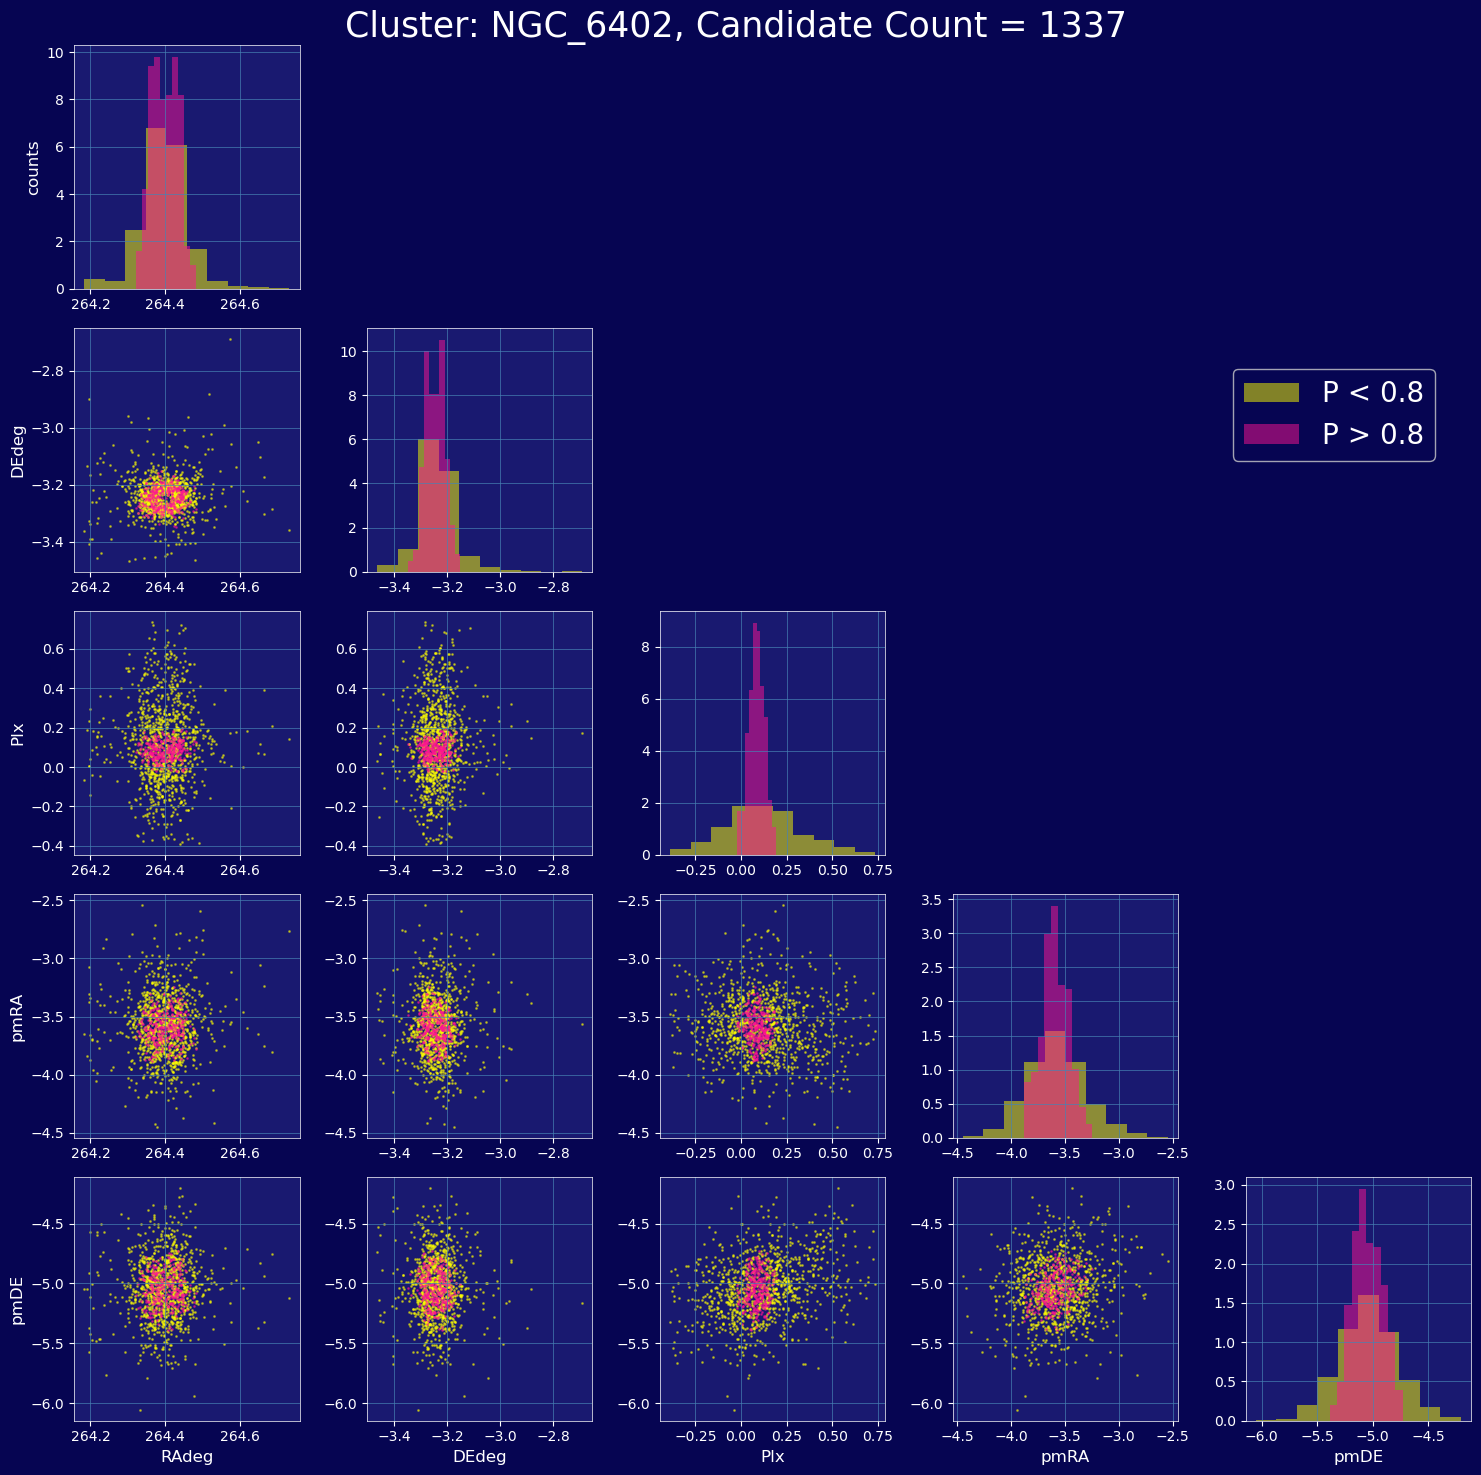

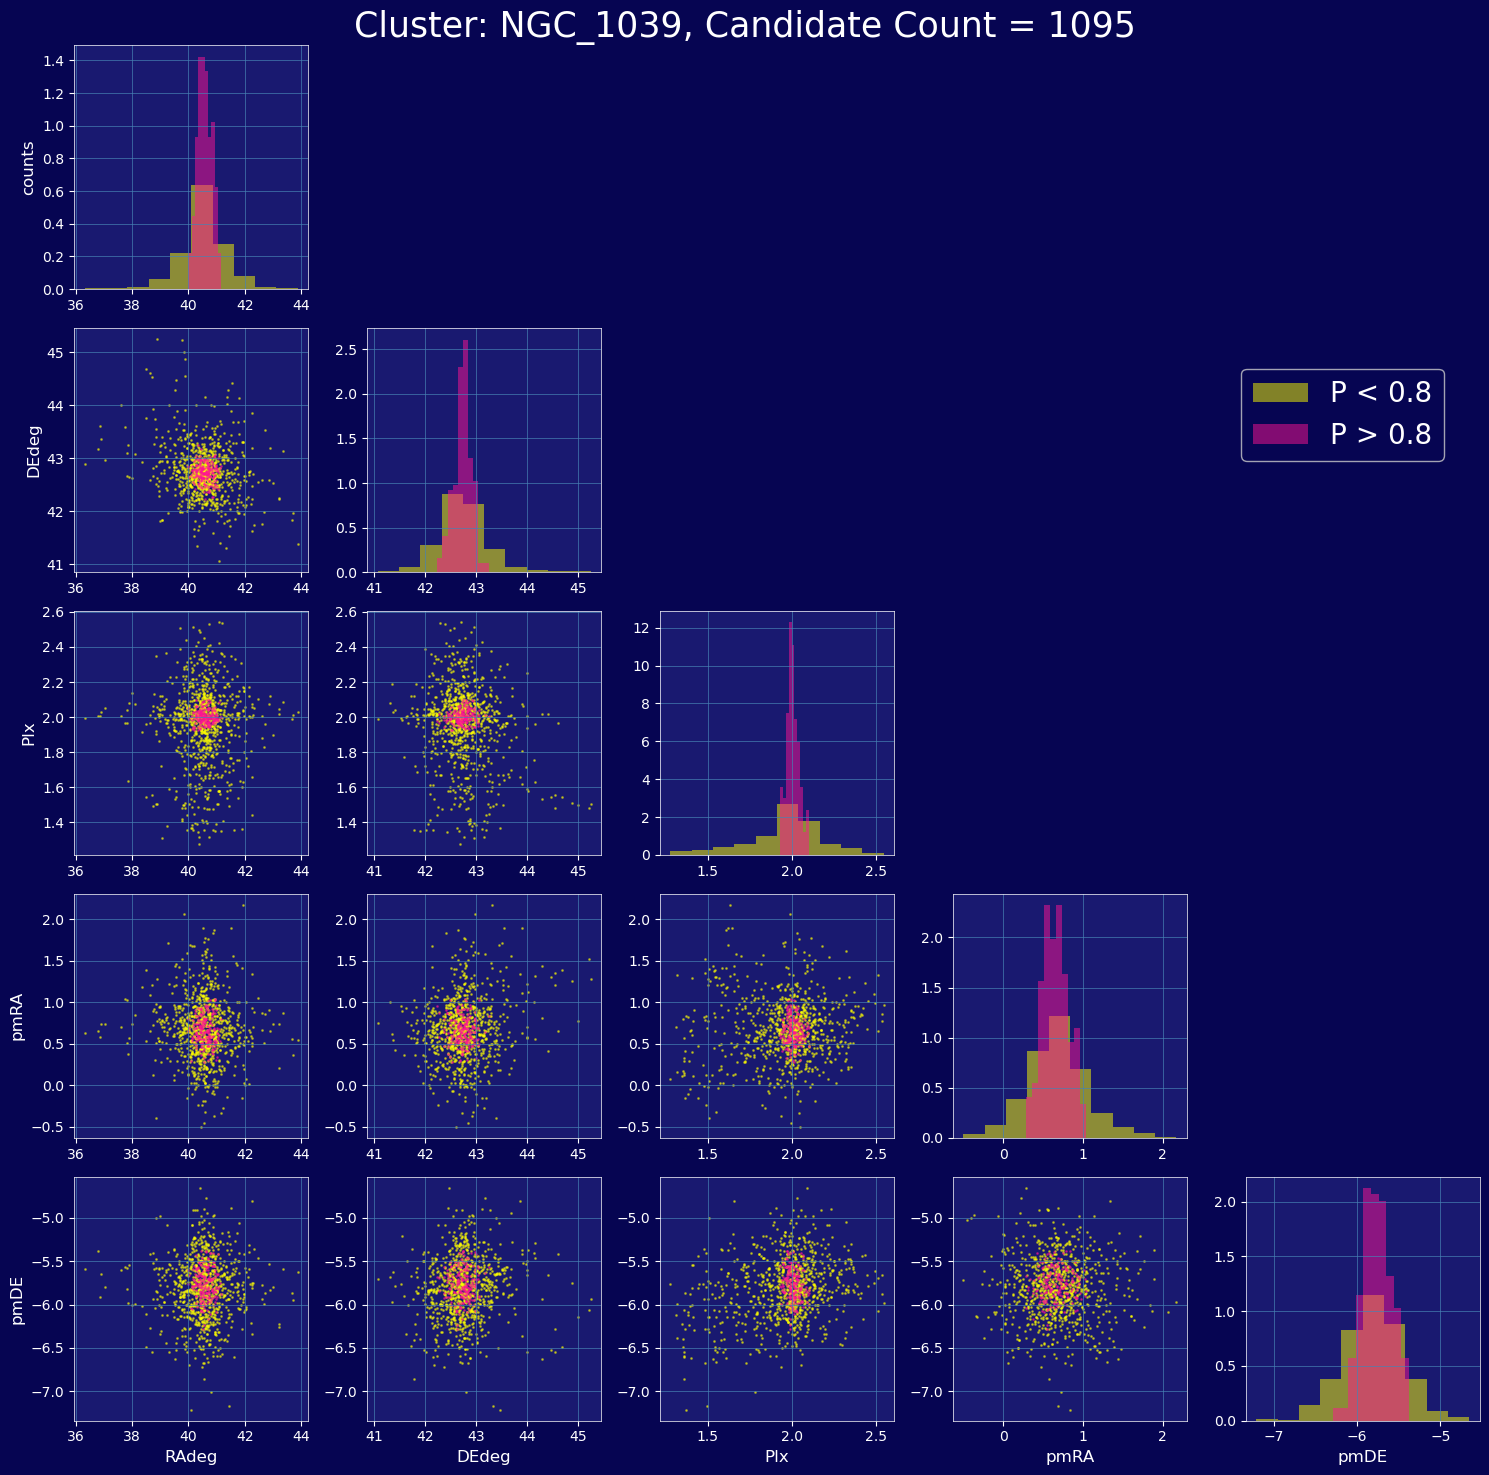

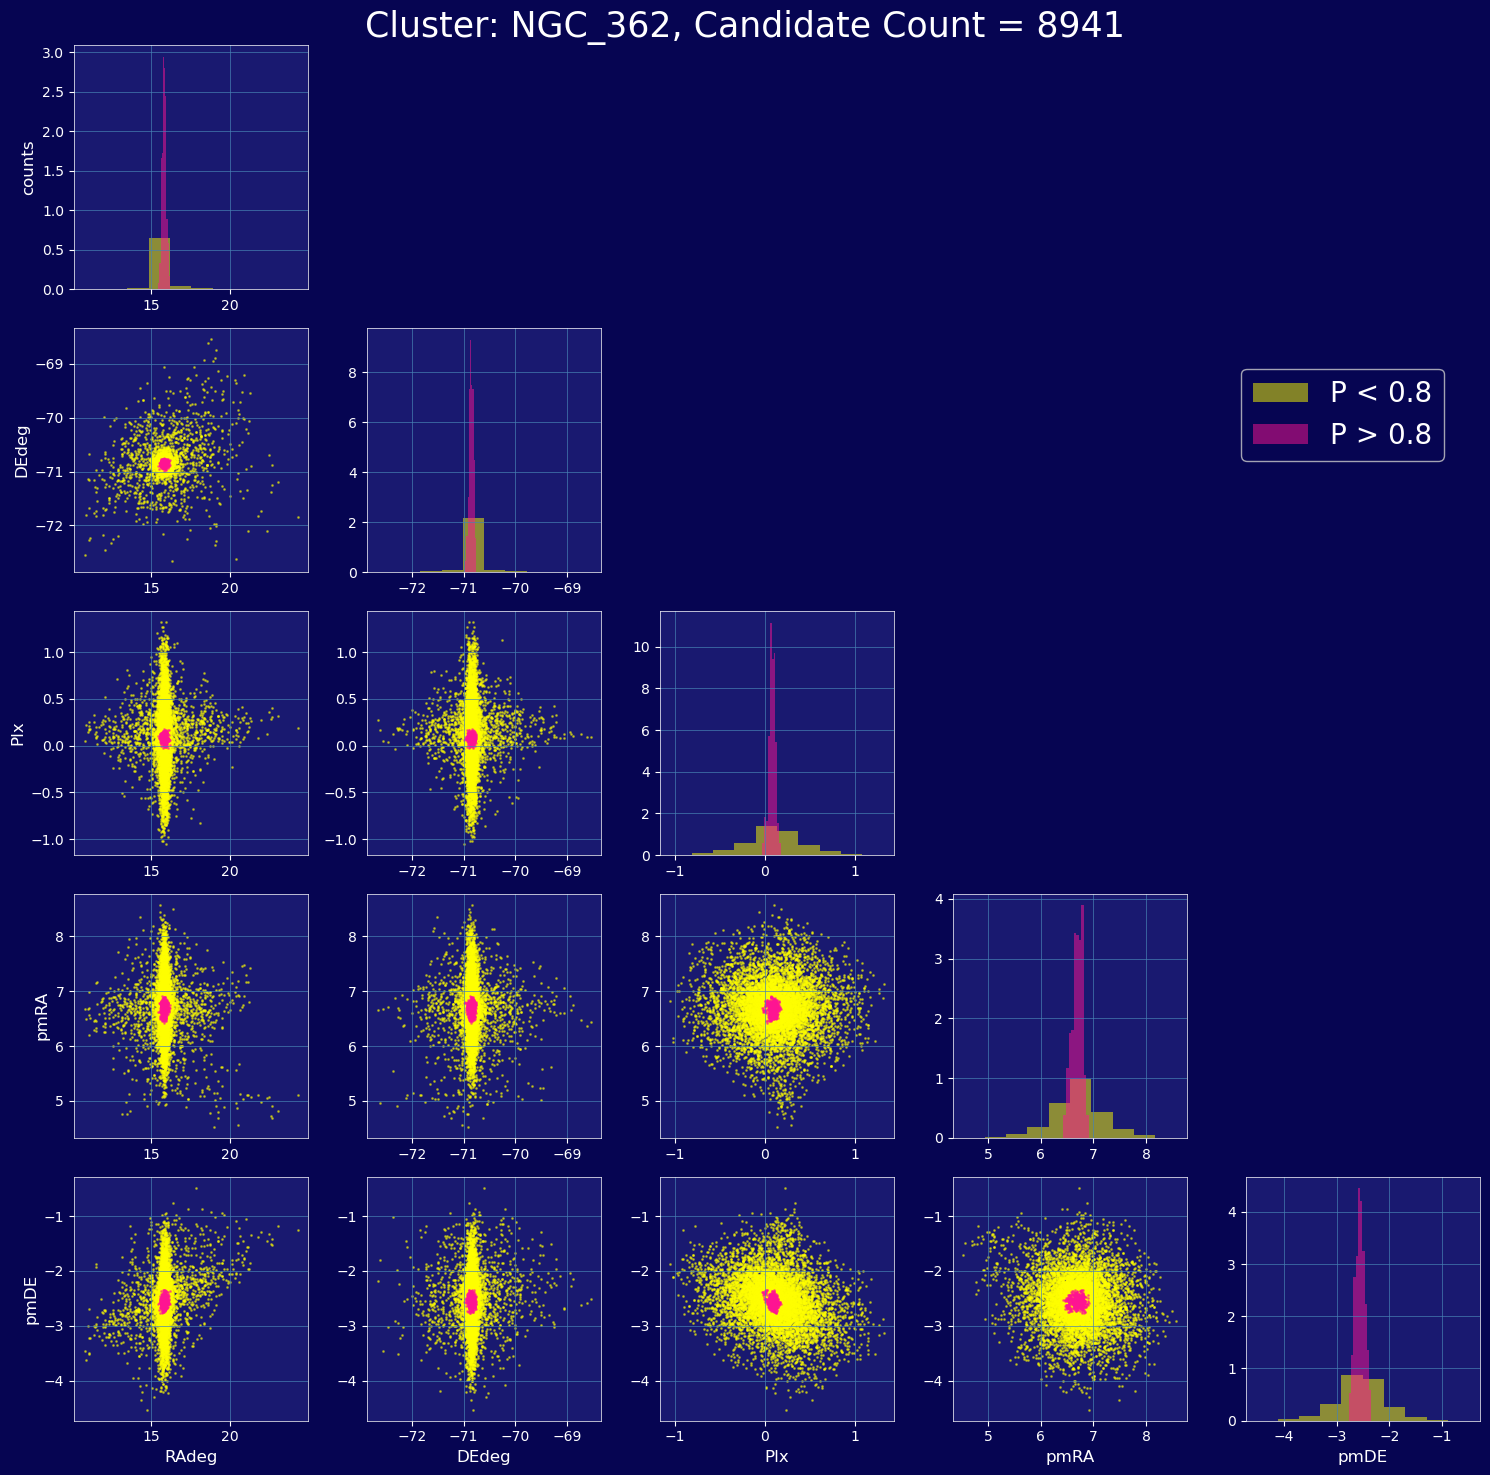

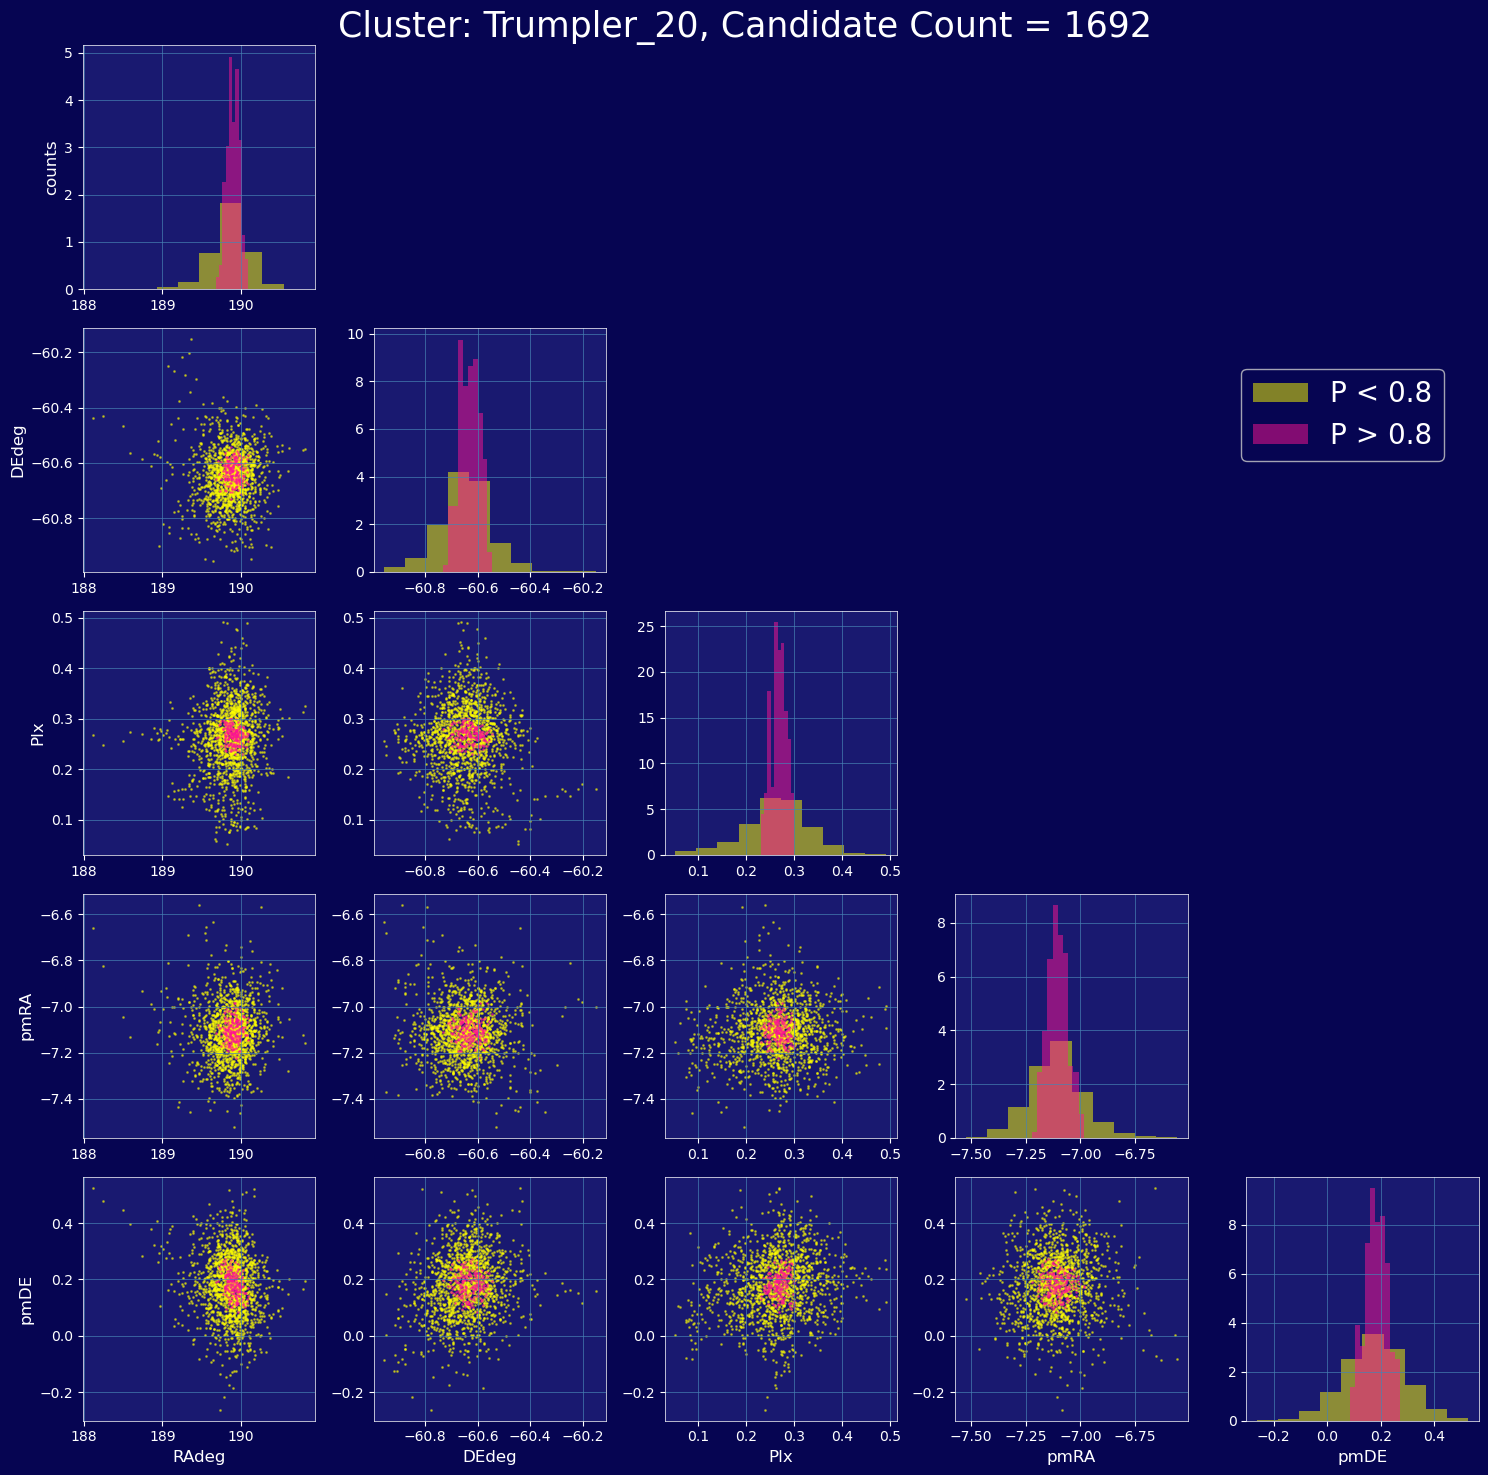

In [15]:
# main df for gt_df = GTp8_cl4stars
# main df for lt_df = LTp8_cl4stars
labels_5param = ['RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']
cluster_names = ['NGC_6402','NGC_1039','NGC_362','Trumpler_20']

for cluster in cluster_names: 
    cluster_scatter_matrix(cluster, LTp8_cl4stars, GTp8_cl4stars, labels_5param)

*For each cluster, answer the following questions, and explain the reasoning for your answer.*
*For each answer, include one quoted observation (e.g. “the clouds overlap almost entirely in pmDE”), and one Figure number where that observation is apparent:*
* *Which pair of dimensions most strongly separates high- and low-Prob stars? **Choose exactly one: RA–Dec, Parallax–pmRA, pmRA–pmDE***
* *Which dimension contributes least to separation? **Choose exactly one: RA, Dec, Parallax, pmRA, pmDE***
* *Which statement matches best the evidence in your plots?*
    *1. The algorithm primarily exploits spatial clustering (i.e. in position)*
    *2. The algorithm primarily exploits kinematic coherence (i.e. in stellar motion)*
    *3. The separation is weak and likely noise-dominated.*

### Cluster NGC_6402: 
1. I would say that `Plx-DEdeg` most strongly separates high- and low-prob stars, as it is clearly the least uniformly distributed between the parameters (spread out in y-direction, cruched in x-direction). I also think it is interesting that the Plx-proper motion plots appear more asymmetric (with some possible tilt).
2. `pmRA` contributes the least to separation (most uniformly distributed). 
3. The algorithm primarily exploits spatial clustering , given that Plx-DEdeg seems the strongest effect and proper motion seems negligible. 

### Cluster NGC_1039: 
1. `Plx-RAdeg` seems to separate the two groups the most, it is a bit harder to see, but the high probability stars are more concentrated compared to the other plots.  
2. pmRA seems to contribute the least to separation, which I notice the most in the pmDE-pmRA plot, where the scatter distribution looks quite spread out and shared. 
3. The algorithm primarily exploits spatial clustering (based on answers 1 and 2). 

### Cluster NGC_362: 
1. `Plx-RAdeg` seems to most strongly separate the groups; while there is clear separation in all of these plots, the spatial ones are the strongest (most concentrated pink blob of high-probability stars). This is also indicated by the sharp, narrow distribution of the high-probability stars in the PDFs for the two spatial grid parameters. However I note that it is interesting that in the `RAdeg-pmDE` plot there is both strong separation *and* some kind of skewing/asymmetry. I wonder if this is because the cluster itself (second to top left) is a bit asymmetric itself in its distribution. 
2. `pmRA` seem to contribute the least (when comparing the two proper motion vs. parallax plots, I see that when parallax is involved, the pmDE plot is skewed, versus the pmRA stays pretty uniformly distributed, so I assume pmDE has a slightly larger contribution.) 
3. Algorithm primarily exploits spatial clustering (based on answers 1 and 2).

### Trumpler_20: 
1. The separation here feels harder to distinguish. `RAdeg-pmDE` seems to separate the groups the most, as the distributions appear the most distinguished, but not by much. 
2. `pmRA` seems to contribute the least, as its distribution appears the most spread between the two groups.
3. Given that I wrote that kinematic coherence seemed influential (answer 1) while also not very influential (answer 2), I will say the *separation is too weak and likely noise-dominated*. Especially also because the PDFs of the higher probabiliy group appear to have the highest dispersion (and overlap with the low probability group) in this scatter plot matrix compared to the other three. 

#### ***1c.** Self-check: Briefly, answer the following two questions: Could this explanation have been written without looking at any Gaia data? If yes, go back and make sure your answers are backed up with observations from your figures.*

I don't think these explanations could be made without looking at Gaia data, since there is some nuance in my answers.

#### *Which observation changes the most between different clusters?*

This feels also hard to answer definitively, as the plots seem to all change a lot between different clusters. One thing I did notice changing was the range of possible values (the x-axis) in the histograms, specifically with the proper motion plots. At first I though this might just be a question of sample size (because the cluster with the largest number of candidates, NGC_362, had noticeably wider distriutions especially in the proper motion parameters). But then comparing the second highest count cluster Trumpler_20 (count = 1692) and the lowest, NGC_1039 (1095), I cannot infer a relationship between candidate count and the possibility range. For example: for NGC_1039 (c = 1095) RAdeg hist is between 36-44. NGC_6402 (c = 1335)'s range is about 264.2 - 264.8 for the same plot, while NGC_632 (c = 8941)'s is 10-25. This difference is observable also in the proper motion histograms as well, and also does not appear to correspond to sample size (pmDE histogram range for lowest count ~ 3, highest count ~ 5, second highest ~ 0.5) 

I now realize this might have to do with the instrument/observations (things I do not understand about these values), which still does not feel completely intuitive given that these are all absolute measurements being derived from observations made with the same instrument (Gaia). 

----------------------------------------------------------------

## *2. Exploratory Data Analysis and Hypothesis Testing (6pts):*
#### *We would like to select clusters that are tightly clustered together, to rule out looser associations which will have a wide spatial variance in their parameters due to the range of distances from us.*

In [278]:
stars.columns

Index(['Name', 'ID', 'GaiaDR3', 'inrt', 'Prob', 'RAdeg', 'e_RAdeg', 'DEdeg',
       'e_DEdeg', 'GLON', 'GLAT', 'pmRA', 'e_pmRA', 'pmDE', 'e_pmDE', 'Plx',
       'e_Plx', 'pscol', 'e_pscol', 'PlxpmRACor', 'PlxpmDECor', 'pmRApmDECor',
       'PlxpscolCor', 'pmRApscolCor', 'pmDEpscolCor', 'Solved', 'ELAT',
       'nueff', 'RUWE', 'FidelityV1', 'FG', 'e_FG', 'FBP', 'e_FBP', 'FRP',
       'e_FRP', 'Gmag', 'BPmag', 'RPmag', 'BP-RP', 'BP-G', 'G-RP', 'RV',
       'e_RV', 'n_RV', 'o_RV', 'o_RVd', 'GRVSmag', 'e_GRVSmag', 'o_GRVSmag',
       'Vbroad', 'e_Vbroad', 'o_Vbroad', 'VarFlag', 'NSS', 'RVS', 'Prob std'],
      dtype='object')

In [ ]:
# FROM THE ASSIGNMENT PDF: 

p_thres = 0.8 # !! select your threshold here !!
stars_hiprob = stars[stars.Prob > p_thres] # stars.Prob? clarify function
clusters_hiprob = stars_hiprob.groupby(['Name']).size().reset_index(name='count')
clusters_sd_hiprob = stars_hiprob.groupby(['Name']).std(numeric_only=True).reset_index()
clusters_hiprob['sd_RAdeg'] = clusters_sd_hiprob['RAdeg']
clusters_hiprob['sd_DEdeg'] = clusters_sd_hiprob['DEdeg']

clusters_hiprob

,Name,count,sd_RAdeg,sd_DEdeg
0,1636-283,30,0.038488,0.032713
1,ADS_16795,41,5.028249,2.071391
2,AH03_J0748+26.9,28,0.029759,0.034522
3,ASCC_100,87,0.848365,0.904561
4,ASCC_101,149,0.519560,0.886064
...,...,...,...,...
7162,vdBergh_152,25,0.863601,0.201857
7163,vdBergh_80,93,0.336260,0.260737
7164,vdBergh_83,92,0.283638,0.200000
7165,vdBergh_85,105,0.107164,0.077127


*Now use the new `clusters_hiprob` dataframe to make a new cluster sample containing only clusters with > 200 stars and standard deviations of RA and Dec < 0.1° (to constrain the cluster size). An interesting question is whether there is any spatial (RA and Dec) variation of the other astrometric and photometric parameters in each cluster.*

In [ ]:
# filtering for counts above 200 in each cluster
cl_hiprob_gt200 = clusters_hiprob[clusters_hiprob['count']>200].sort_values('count')
print('cluster high probability, count greater than 200:')
cl_hiprob_gt200

cluster high probability, count greater than 200:


,Name,count,sd_RAdeg,sd_DEdeg
4292,IC_2714,202,0.132322,0.065206
6124,UBC_106,202,0.058114,0.053156
6059,Trumpler_25,202,0.042934,0.035774
4580,NGC_2632,203,0.504105,0.491808
4652,NGC_5617,203,0.106845,0.047543
...,...,...,...,...
4783,NGC_6656,1767,0.067718,0.069157
5921,Theia_6046,2925,0.841412,1.159279
3864,HSC_655,3047,0.355850,0.189797
5785,Theia_3623,3086,0.556936,0.293170


In [ ]:
# filtering for standard deviation
clhp_gt200_stdltp1 = cl_hiprob_gt200[(cl_hiprob_gt200['sd_DEdeg'] < 0.1) & (cl_hiprob_gt200['sd_RAdeg'] < 0.1)]
print('cluster high probability, count greater than 200 and standard deviations less than 0.1:')
clhp_gt200_stdltp1 

cluster high probability, count greater than 200 and standard deviations less than 0.1:


,Name,count,sd_RAdeg,sd_DEdeg
6124,UBC_106,202,0.058114,0.053156
6059,Trumpler_25,202,0.042934,0.035774
4720,NGC_6352,203,0.043012,0.027194
4734,NGC_6402,203,0.032112,0.033235
4725,NGC_6366,204,0.022493,0.022993
6052,Trumpler_19,206,0.093484,0.047014
4630,NGC_4755,207,0.079174,0.035100
4588,NGC_2682,209,0.079541,0.059787
1315,Collinder_110,210,0.073291,0.069916
4534,NGC_2360,216,0.090189,0.070685


In [19]:
# doing number selection here, immediately to report in cell below
random_cluster = np.random.choice(clhp_gt200_stdltp1['Name'], size=1)
print(random_cluster)

['NGC_2682']


### NOTE: my randomly-selected cluster is HSC_186.
(Again, I did not know about the "seed" method at this point in the project, and ran the cell above to chose this cluster.) 

***2a.** Randomly select one filtered cluster, note down its name and the random seed you used in the notebook. Before making any new plots, based on your previous analysis, answer:*

* *Will the parallax distribution vary with RA?*
* *Will proper motion dispersion increase, decrease or stay constant with RA and Dec?*

*Justify each choice in one sentence, noting down which previous figure/result you base your prediction on. To be clear: incorrect predictions will not be penalized, you will be graded on the coherence of your argument, not on the correctness of the prediction.*

**1. Will the parallax distribution vary with RA?**

I do not think the parallax distribution will vary with RA, both from an astrophysics standpoint and also graphically. Graphically, the third scatter plot matrix about NGC_362 (the largest number of candidates) made me realize that most values in principle should not really vary along RA and DEC measurements for a proper cluster, in part because it is the same observation but more so (physically) because if it really is a cluster, the distance from each star should not vary so drastically so as to be observable in a plot like this. Dispersion should only be due to instrumental/measurement noise. Because I have now filtered to only include data of very tightly-clustered systems, parallax should not vary. 

**2. Will proper motion dispersion increase, decrease, or stay constant with RA and DEC?**

Now looking back, I am better recognizing the relationship between the tightness of clustering and the dispersion of proper motion; based on the fact that Trumpler_20 (4th cluster plot) was the most clustered at least in Declination (y axis of DEdeg vs. RAdeg), and the pmDE dispersion was minimized (range of ~0.5, bottom right histogram), I predict that the proper motion dispersion, compared to the previous plots, should decrease given that standard deviations of RA and Dec have been minimized; but it should remain constant in the plots I now produce. 

#### ***2b.** Now split it into 2 subsamples in RA, corresponding to stars with RA: i) greater than the mean RA, ii) less than the mean RA. Do the same for Dec, to create 2 subsamples selected on mean Dec.* 

#### Now, will be: 
Splitting into two subsamples in `RA`: 
1. $RA \gt \langle RA \rangle$
2. $RA \lt \langle RA \rangle$

Splitting into two subsamples in `Dec`: 
1. $Dec \gt \langle Dec \rangle$
2. $Dec \lt \langle Dec \rangle$


In [ ]:
my_cluster = stars[stars['Name'] == 'HSC_186'] # pulling out randomly selected cluster
my_cluster

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
215826,HSC_186,1932,4098039472071049088,1,1.000000,275.419474,0.118330,-15.796145,0.112522,15.527798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215827,HSC_186,1932,4098039437711360896,1,0.990168,275.438064,0.173737,-15.785955,0.168054,15.545203,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215828,HSC_186,1932,4098039403351576064,1,0.992957,275.427780,0.180885,-15.795391,0.173335,15.532221,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215829,HSC_186,1932,4098039373298532608,1,1.000000,275.410186,0.084593,-15.799929,0.078863,15.520256,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
215830,HSC_186,1932,4098039334632033536,1,1.000000,275.385595,0.038676,-15.808947,0.036627,15.501169,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216067,HSC_186,1932,4098034459839447040,0,0.970536,275.250431,0.111786,-15.879223,0.104260,15.377961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
216068,HSC_186,1932,4098033665280070400,0,1.000000,275.377994,0.034288,-15.811709,0.033131,15.495291,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
216069,HSC_186,1932,4098033630915412096,0,0.948903,275.368583,0.073905,-15.818396,0.081616,15.485130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0
216070,HSC_186,1932,4098033596555659776,0,0.953972,275.332679,0.159167,-15.819397,0.145345,15.467993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOT_AVAILABLE,0,0


Personal question: would I have gotten the same table if I'd filtered using the `e_RAdeg` and `e_DEdeg` values instead of using standard deviation? 

Average RAdeg: 275.4213627192683
Average DEdeg: -15.823392489105691


Text(0.5, 1.0, 'Dec Distribution')

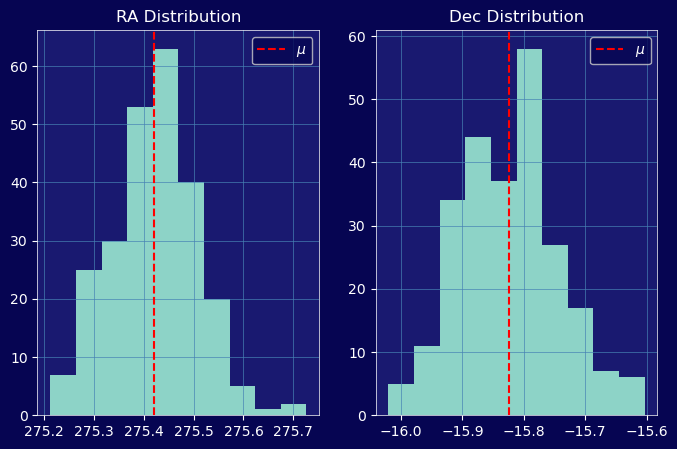

In [ ]:
print(f"Average RAdeg: {np.mean(my_cluster['RAdeg'])}")
print(f"Average DEdeg: {np.mean(my_cluster['DEdeg'])}")

# just out of curiosity
fig, ax = plt.subplots(1,2, figsize = (8,5))
ax[0].hist(my_cluster['RAdeg'])
ax[0].axvline(np.mean(my_cluster['RAdeg']), ls = 'dashed', color = 'red', label = r'$\mu$')
ax[0].legend()
ax[0].set_title('RA Distribution')
ax[1].hist(my_cluster['DEdeg'])
ax[1].axvline(np.mean(my_cluster['DEdeg']), ls = 'dashed', color = 'red', label = r'$\mu$')
ax[1].legend()
ax[1].set_title('Dec Distribution')


In [ ]:
# splitting by above and below the mean (center of cluster) 
RA_ltmean = my_cluster[my_cluster['RAdeg'] < np.mean(my_cluster['RAdeg'])]
RA_gtmean = my_cluster[my_cluster['RAdeg'] > np.mean(my_cluster['RAdeg'])]
Dec_ltmean = my_cluster[my_cluster['DEdeg'] < np.mean(my_cluster['DEdeg'])]
Dec_gtmean = my_cluster[my_cluster['DEdeg'] > np.mean(my_cluster['DEdeg'])]
# put back into single objects
RAs = [RA_ltmean, RA_gtmean]
Decs = [Dec_ltmean, Dec_gtmean]

* show the histograms of the following parameters for each of the 2 subsamples: `Plx`, `pmRA`, `pmDE`, `Gmag` and `BP-RP`. 

In [294]:
def plotter_2b_w_genmean(spatial_var, var_name, cluster, suptitle): 

    fig, ax = plt.subplots(5, 2, figsize = (8,20))

    # ---- parallax ----
    # less than mean 
    ax[0,0].hist(spatial_var[0]['Plx'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[0,0].axvline(np.mean(spatial_var[0]['Plx']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["Plx"]):.3f}')
    ax[0,0].axvline(np.mean(cluster["Plx"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Plx"]):.3f}')
    ax[0,0].legend()
    ax[0,0].set_title(f'Parallax below mean {var_name}')
    # greater than mean
    ax[0,1].hist(spatial_var[1]['Plx'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[0,1].axvline(np.mean(spatial_var[1]['Plx']), color = 'gold', ls = 'dashed', label = f'$\mu$ = {np.mean(spatial_var[1]["Plx"]):.3f}')
    ax[0,1].axvline(np.mean(cluster["Plx"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Plx"]):.3f}')
    ax[0,1].legend()
    ax[0,1].set_title(f'Parallax above mean {var_name}')

    # --- proper motion RA ---
    # less than mean 
    ax[1,0].hist(spatial_var[0]['pmRA'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[1,0].axvline(np.mean(spatial_var[0]['pmRA']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["pmRA"]):.3f}')
    ax[1,0].axvline(np.mean(cluster["pmRA"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmRA"]):.3f}')    
    ax[1,0].legend()
    ax[1,0].set_title(f'pmRA below mean {var_name}')
    # greater than mean 
    ax[1,1].hist(spatial_var[1]['pmRA'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[1,1].axvline(np.mean(spatial_var[1]['pmRA']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["pmRA"]):.3f}')
    ax[1,1].axvline(np.mean(cluster["pmRA"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmRA"]):.3f}')    
    ax[1,1].legend()
    ax[1,1].set_title(f'pmRA above mean {var_name}')

    # --- proper motion Dec ---
    # less than mean 
    ax[2,0].hist(spatial_var[0]['pmDE'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[2,0].axvline(np.mean(spatial_var[0]['pmDE']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["pmDE"]):.3f}')
    ax[2,0].axvline(np.mean(cluster["pmDE"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmDE"]):.3f}')    
    ax[2,0].legend()
    ax[2,0].set_title(f'pmDE below mean {var_name}')
    # greater than mean
    ax[2,1].hist(spatial_var[1]['pmDE'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[2,1].axvline(np.mean(spatial_var[1]['pmDE']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["pmDE"]):.3f}')
    ax[2,1].axvline(np.mean(cluster["pmDE"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmDE"]):.3f}')    
    ax[2,1].legend()
    ax[2,1].set_title(f'pmDE above mean {var_name}')

    # --- G-Magnitude ---
    # less than mean
    ax[3,0].hist(spatial_var[0]['Gmag'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[3,0].axvline(np.mean(spatial_var[0]['Gmag']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["Gmag"]):.3f}')
    ax[3,0].axvline(np.mean(cluster["Gmag"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Gmag"]):.3f}')    
    ax[3,0].legend()
    ax[3,0].set_title(f'Gmag below mean {var_name}')
    # greater than mean
    ax[3,1].hist(spatial_var[1]['Gmag'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[3,1].axvline(np.mean(spatial_var[1]['Gmag']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["Gmag"]):.3f}')
    ax[3,1].axvline(np.mean(cluster["Gmag"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Gmag"]):.3f}')    
    ax[3,1].legend()
    ax[3,1].set_title(f'Gmag above mean {var_name}')

    # --- BP-RP (photometric?) ---
    # less than mean 
    ax[4,0].hist(spatial_var[0]['BP-RP'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    ax[4,0].axvline(np.mean(spatial_var[0]['BP-RP']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[0]["BP-RP"]):.3f}')
    ax[4,0].axvline(np.mean(cluster["BP-RP"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["BP-RP"]):.3f}')    
    ax[4,0].legend()
    ax[4,0].set_title(f'BP-RP below mean {var_name}')
    # greater than mean
    ax[4,1].hist(spatial_var[1]['BP-RP'], density = True, bins = 25, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    ax[4,1].axvline(np.mean(spatial_var[1]['BP-RP']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset}}$ = {np.mean(spatial_var[1]["BP-RP"]):.3f}')
    ax[4,1].axvline(np.mean(cluster["BP-RP"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["BP-RP"]):.3f}')        
    ax[4,1].legend()
    ax[4,1].set_title(f'BP-RP above mean {var_name}')
    
    plt.suptitle(suptitle, size=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    
    


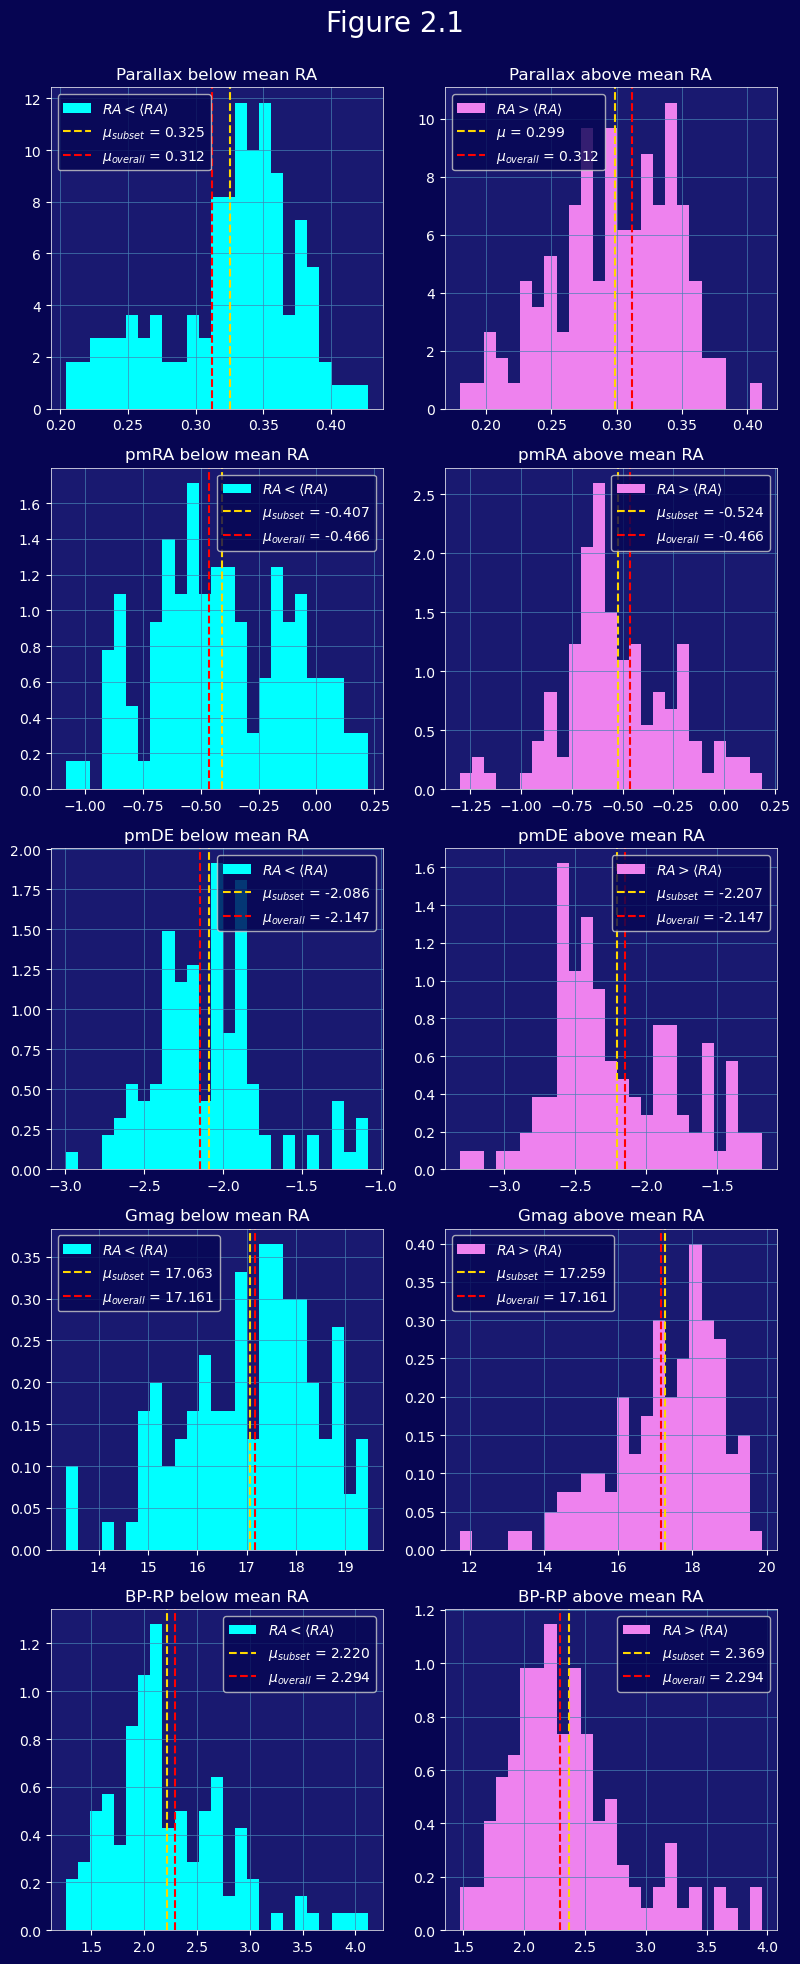

In [295]:
plotter_2b_w_genmean(RAs, var_name = 'RA', cluster = my_cluster, suptitle='Figure 2.1')

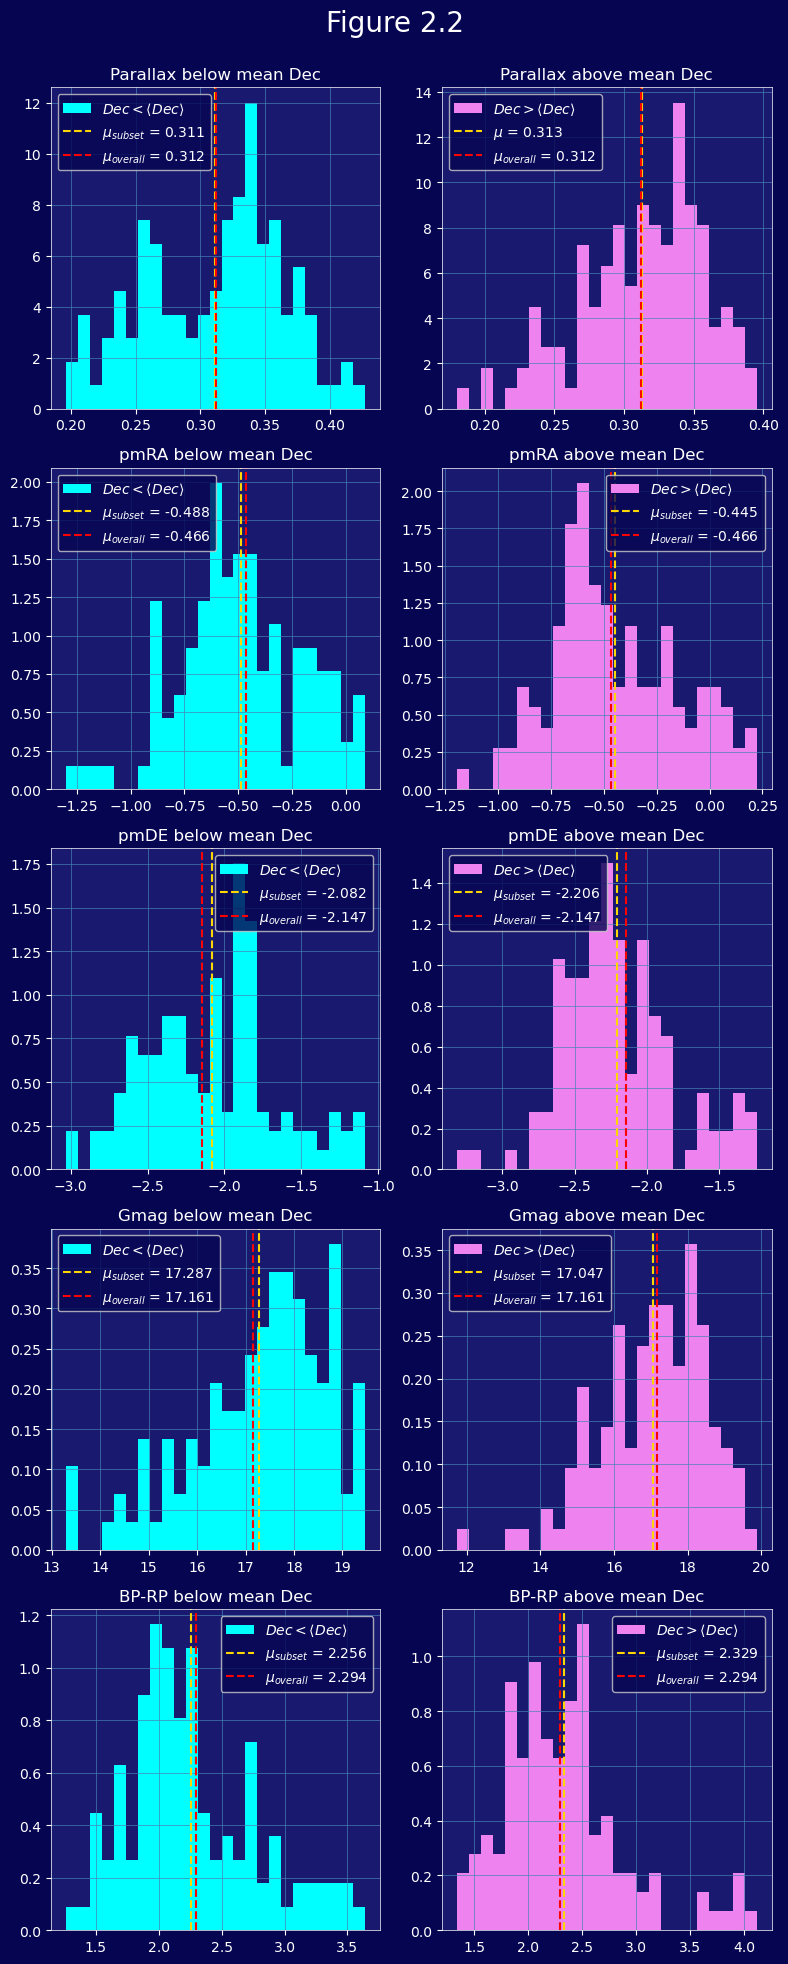

In [296]:
plotter_2b_w_genmean(Decs, var_name = 'Dec', cluster = my_cluster, suptitle='Figure 2.2')

In [ ]:
def overplot_hist_2b_overplot_w_all_means(spatial_var, var_name, cluster, suptitle): 

    '''
    function to plot both subsample histograms overlapping, 
    as well as plot each subsample's mean and the overall sample mean
    specifically for these five parameters: 
    '''
    fig, ax = plt.subplots(5, 1, figsize = (10,18))

    # ---- parallax ----
    # less than mean 
    ax[0].hist(spatial_var[0]['Plx'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[0].hist(spatial_var[1]['Plx'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs & plot  
    ax[0].axvline(np.mean(spatial_var[0]['Plx']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["Plx"]):.3f}')
    ax[0].axvline(np.mean(spatial_var[1]['Plx']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["Plx"]):.3f}')
    ax[0].axvline(np.mean(cluster["Plx"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Plx"]):.3f}')
    ax[0].legend()
    ax[0].set_title('Parallax')

    # --- proper motion RA ---
    # less than mean 
    ax[1].hist(spatial_var[0]['pmRA'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean 
    ax[1].hist(spatial_var[1]['pmRA'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs and plot
    ax[1].axvline(np.mean(spatial_var[0]['pmRA']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["pmRA"]):.3f}') 
    ax[1].axvline(np.mean(spatial_var[1]['pmRA']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["pmRA"]):.3f}')
    ax[1].axvline(np.mean(cluster["pmRA"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmRA"]):.3f}') 
    ax[1].legend()
    ax[1].set_title('pmRA')

    # --- proper motion Dec ---
    # less than mean 
    ax[2].hist(spatial_var[0]['pmDE'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[2].hist(spatial_var[1]['pmDE'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # greater than mean
    ax[2].axvline(np.mean(spatial_var[0]['pmDE']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["pmDE"]):.3f}')
    ax[2].axvline(np.mean(spatial_var[1]['pmDE']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["pmDE"]):.3f}')
    ax[2].axvline(np.mean(cluster["pmDE"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["pmDE"]):.3f}')    
    ax[2].legend()
    ax[2].set_title('pmDE')

    # --- G-Magnitude ---
    # less than mean
    ax[3].hist(spatial_var[0]['Gmag'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[3].hist(spatial_var[1]['Gmag'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs & plot
    ax[3].axvline(np.mean(spatial_var[0]['Gmag']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["Gmag"]):.3f}')   
    ax[3].axvline(np.mean(spatial_var[1]['Gmag']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["Gmag"]):.3f}')
    ax[3].axvline(np.mean(cluster["Gmag"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["Gmag"]):.3f}')    
    ax[3].legend()
    ax[3].set_title('Gmag')

    # --- BP-RP (photometric?) ---
    # less than mean 
    ax[4].hist(spatial_var[0]['BP-RP'], density = True, bins = 25, color = 'cyan', label = f'${var_name} < \\langle {var_name} \\rangle $')
    # greater than mean
    ax[4].hist(spatial_var[1]['BP-RP'], density = True, bins = 25, alpha = 0.8, color = 'violet', label = f'${var_name} > \\langle {var_name} \\rangle $')
    # avgs & plot
    ax[4].axvline(np.mean(spatial_var[0]['BP-RP']), color = 'gold', ls = 'dashed', label = f'$\mu_{{subset,low}}$ = {np.mean(spatial_var[0]["BP-RP"]):.3f}') 
    ax[4].axvline(np.mean(spatial_var[1]['BP-RP']), color = 'deepskyblue', ls = 'dashed', label = f'$\mu_{{subset,high}}$ = {np.mean(spatial_var[1]["BP-RP"]):.3f}')
    ax[4].axvline(np.mean(cluster["BP-RP"]), color = 'red', ls = 'dashed', label = f'$\mu_{{overall}}$ = {np.mean(cluster["BP-RP"]):.3f}')        
    ax[4].legend()
    ax[4].set_title('BP-RP')

    plt.suptitle(suptitle, size=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    


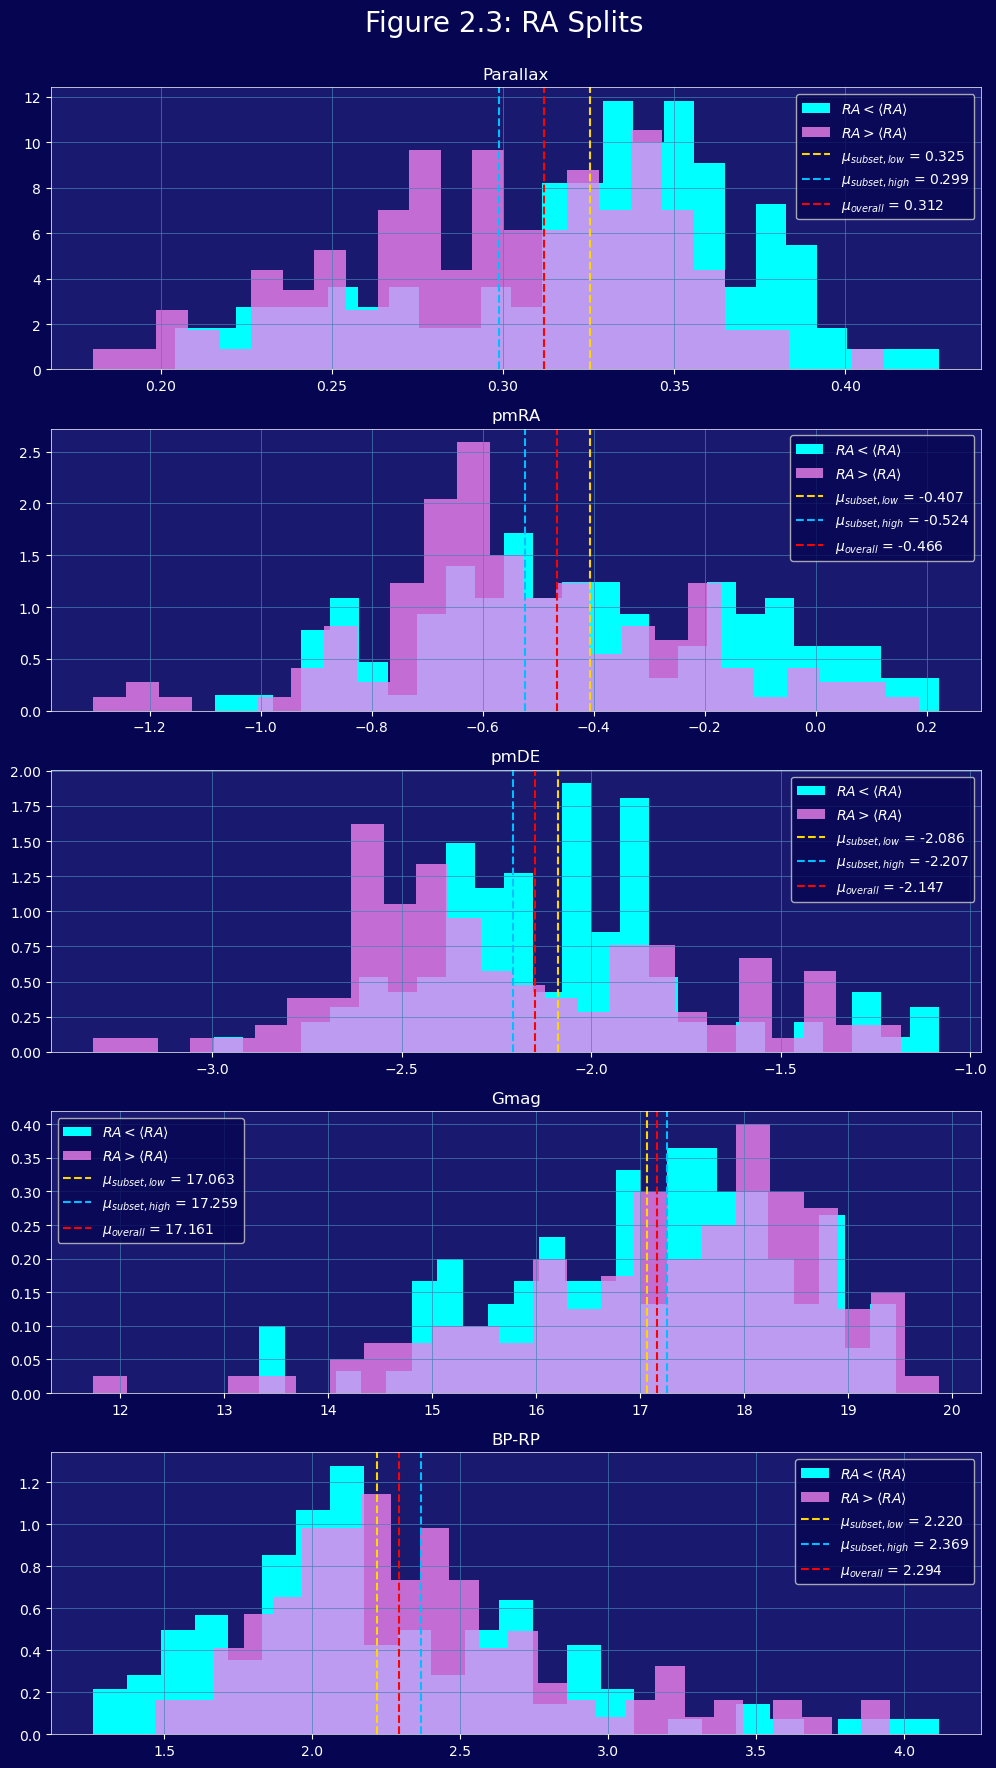

In [311]:
overplot_hist_2b_overplot_w_all_means(RAs, 'RA', my_cluster, suptitle='Figure 2.3: RA Splits')

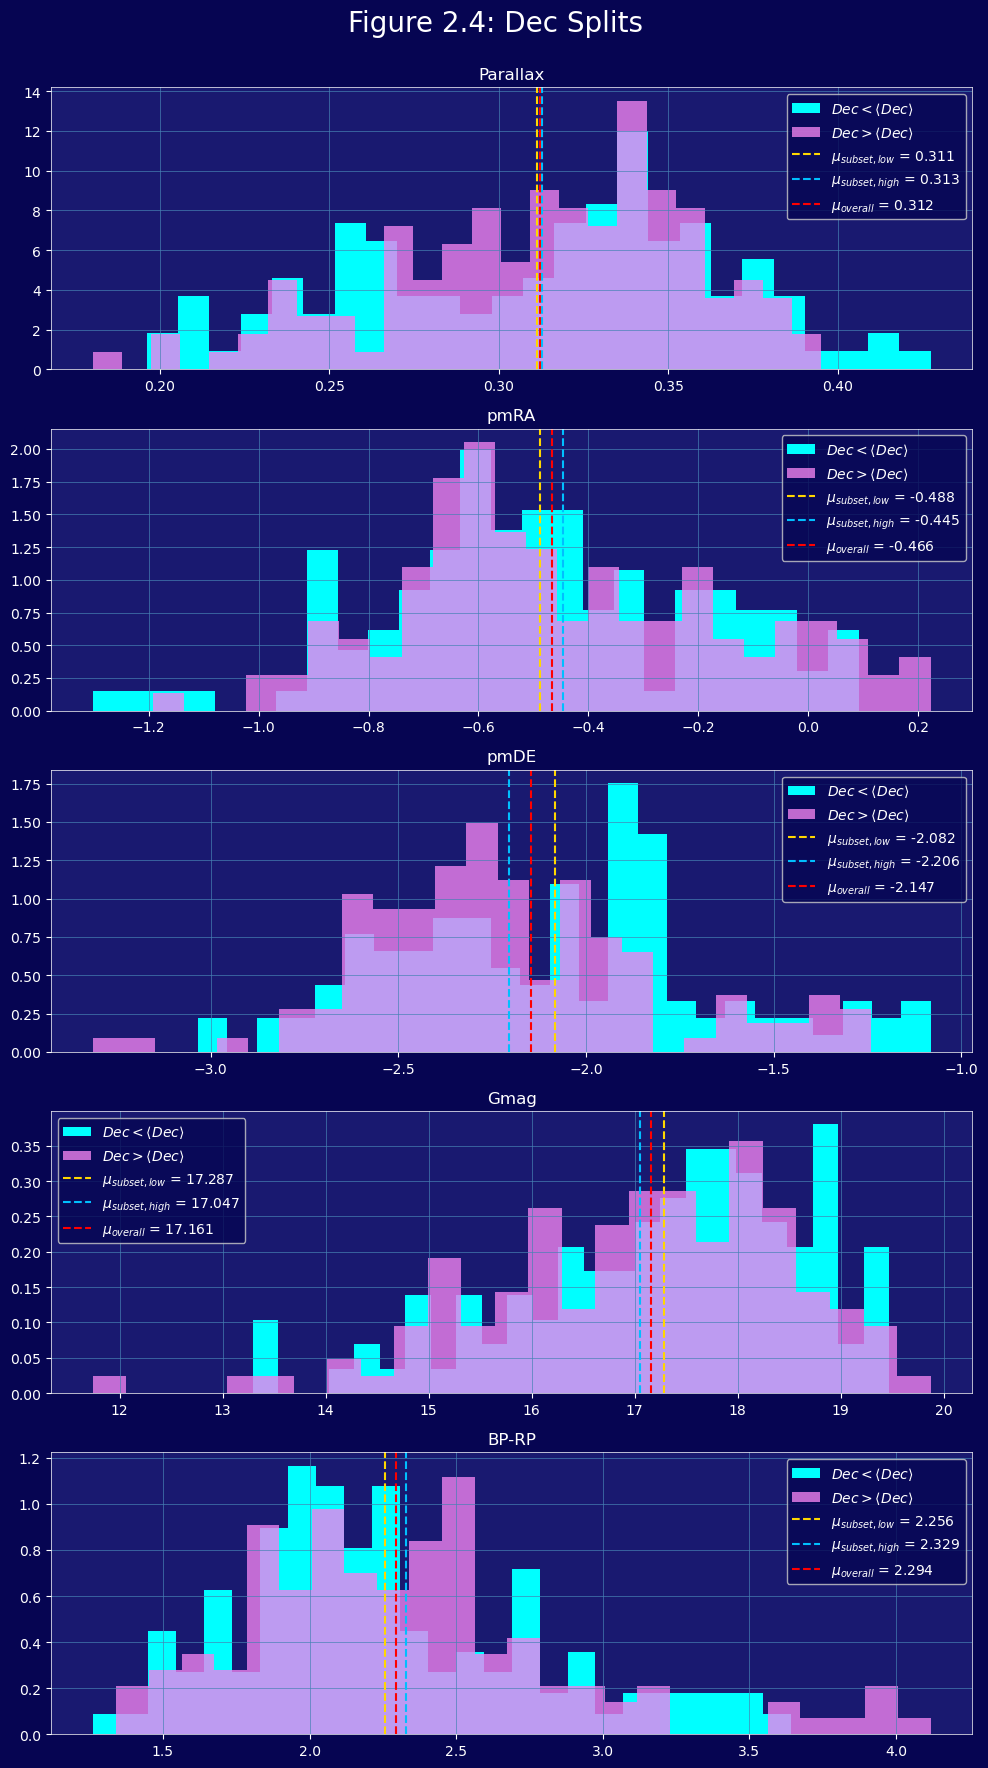

In [300]:
overplot_hist_2b_overplot_w_all_means(Decs, 'Dec', my_cluster, suptitle = 'Figure 2.4: Dec Splits')

#### Okay now just curious and want to look at the cluster itself. 

Text(0.5, 1.0, 'Cluster HSC_186')

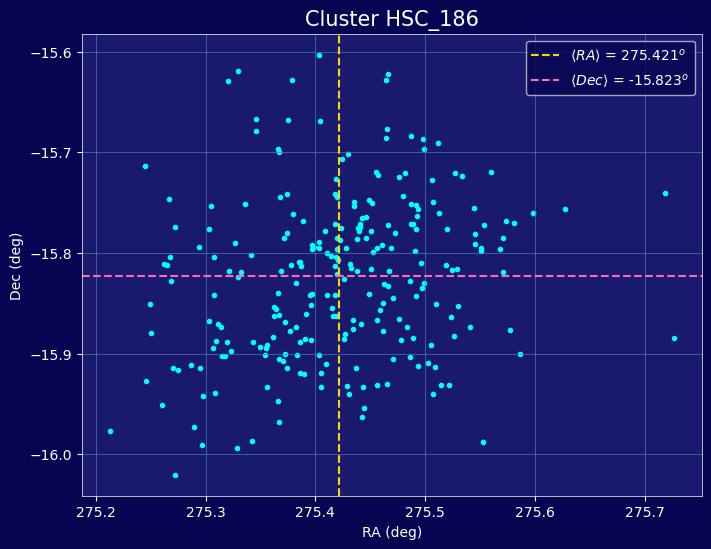

In [301]:
plt.figure(figsize = (8,6))
plt.scatter(my_cluster['RAdeg'], my_cluster['DEdeg'], color = 'cyan', marker='.')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.axvline(np.mean(my_cluster['RAdeg']), ls = 'dashed', color = 'gold', label = f'$\langle RA \\rangle$ = {np.mean(my_cluster["RAdeg"]):.3f}$^o$')
plt.axhline(np.mean(my_cluster['DEdeg']), ls = 'dashed', color = 'hotpink', label = f'$\langle Dec \\rangle$ = {np.mean(my_cluster["DEdeg"]):.3f}$^o$')
plt.legend()
plt.title('Cluster HSC_186', fontsize = 15)

***Did your predictions agree with the data?***

* For parallax: Sort of agrees. I predicted that parallax should not vary with RA and Dec; for Dec, the parallax means of the subsets varied from the overall mean by 0.001 (0.1%), which does not seem that significant. However for RA, parallax does indeed vary significantly, with an absolute difference in subset means $= |0.325 - 0.299| = 0.026$, an order of magnitude greater than the Declination difference. However these subset means still only vary from the overall mean by 1%, which is non-negligible.


* For proper motion: I predicted that the proper motion dispersion should be constant relative to RA and Dec for these plots, but now see that this doesn't make sense, as proper motion dispersion can depend on different parameters, for example in the plot above, the cluster I'm investigating itself is asymmetric around its mean RA and Dec, so its proper motion, for example if the cluster is rotating, should vary across the spatial grid. This is also evident in my histograms of proper motion, which show that it does indeed vary with RA and Dec. (Figures 2.1-2.4)

* Overall, I realize that in my previous predictions, I was relying too much on trying to make some physical inference about these systems rather than focusing on the relevant statistics, especially the hint in the scatter plot matrix about the relationship between the spatial parameters (RA, DEC, Parallax). 

#### ***2c.** Use hypothesis testing via t-tests to compare the 2 subsamples in RA and then the 2 subsamples in Dec for the following parameters: Plx, pmRA, pmDE, Gmag and BP-RP. For the t-test you can assume populations with the same variance. You will do 5 t-tests for the subsamples selected on RA and 5 for the subsamples selected on Dec, to see if there is any evidence that the populations of stars which each subsample is drawn from is different from the other subsample, i.e. does it change with position in the cluster.* 

So, 
* **Null hypothesis:** the population of stars from which each subsample is drawn does not differ with position in the cluster. 
* **Alternative hypothesis:** the population of stars from which each subsample is drawn does differ with position in the cluster. 

#### Building my T-test: 
I think I am going to try to use `scipy.stats.ttest_ind`, based on the T-test function we learned in class, however with equal variance: 
$$
T = \frac{\mu_1 - \mu_2}{s\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}
$$

Already, I am worried about the validity of this method because the T-test assumes: 
- data is continuous (fine) 
- observations are independent, random samples from the population (fine)
- normal distribution; should be fine given the N is large (central limit theorem), however the extent to which this follows is unclear 
- variances of groups are equal (we are given this)

Scipy.stats's function for the two-sample t-test is as follows:  
`ttest_ind(a, b, *, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided', trim=0, method=None, keepdims=False)`

So my `a` and `b` should be the two subsamples (parameters for less than and greater than mean). 

And again, the parameters I'm investigating are `Plx`, `pmRA`, `pmDE`, `Gmag` and `BP-RP`. 

#### Also, I am stating now that my threshold for a statistically significant result is one with a 95% confidence interval, so with a threshold of $p \lt 0.05$.

In [302]:
# testing for RAs first, try parallax
test = sp.stats.ttest_ind(a = RAs[0]['Plx'], 
                          b = RAs[1]['Plx'])
test2 = sp.stats.ttest_ind(a = Decs[0]['Plx'], 
                           b = Decs[1]['Plx'])
print(test, test2, f'len = {len(test)}')

TtestResult(statistic=4.376528848187094, pvalue=1.7888279979764405e-05, df=244.0) TtestResult(statistic=-0.23094814097620117, pvalue=0.8175486245374954, df=244.0) len = 2


In [ ]:
# okay now actually writing function to just compute t-test for the subsets

def compute_t_test_table(set): 
    '''compute t-test and put into dataframe'''
    params = ['Plx', 'pmRA', 'pmDE', 'Gmag', 'BP-RP']
    t_test_results = {}
    for param in params: 
        t_stat, pvalue = sp.stats.ttest_ind(a = set[0][param], b = set[1][param]) # 
        t_test_results[param] = {'T-Statistic': t_stat, 
                                 'p-value': pvalue}
    results_df = pd.DataFrame(t_test_results)
    return results_df


In [304]:
RA_results = compute_t_test_table(RAs)
print('RA Subset Comparison Results')
RA_results

RA Subset Comparison Results


,Plx,pmRA,pmDE,Gmag,BP-RP
T-Statistic,4.376529,3.156269,2.314694,-1.076247,-2.184065
p-value,0.000018,0.001799,0.021461,0.282880,0.029910


In [305]:
Dec_results = compute_t_test_table(Decs)
print('Dec Subset Comparison Results')
Dec_results

Dec Subset Comparison Results


,Plx,pmRA,pmDE,Gmag,BP-RP
T-Statistic,-0.230948,-1.134628,2.378023,1.316928,-1.059319
p-value,0.817549,0.257645,0.018177,0.189098,0.290502


c. Answer: Given these results, there is evidence that the populations of stars which each subsample is drawn from *is* different from the other subsample, evidenced by the statistically significant values in the right-ascension subsamples. 
* For the **RA** results: parallax, proper motion (both in RA and Dec) and the photometric BP-RP have $p$-values of less than 0.05, which I defined as my threshold for significance, suggesting that for those parameters, I can reject the null hypothesis in 4 out of 5 parameters. 
* For the **Dec** results: only proper motion in declination has a $p$-value less than the threshold, so I can reject the null hypothesis in 1 out of 5 parameters. 

Thus there is some evidence for change with position in the cluster. 

* *Identify one test result that you believe may not reflect reality. Fill in the blanks in this sentence: “This test is misleading because the histograms in Figure ___ show ___, which violates the assumption of ___.” If you don’t believe any test results are in conflict with what you see in the Figures, fill in the blanks in the following sentence. “No tests are misleading. For example, the histograms in Figure ___ show ___, which is in line with the assumption of ___ required by the t-test.”* 

    * One test that I believe may not reflect reality is the p-value on the `Gmag` parameter. This test is misleading because 
        - RA comparison Histogram has Gmag:
            - $\mu_{subset, low} < \mu_{overall} < \mu_{subset, high}$
            - which means that moving from left to right, the cluster is brighter in the G band.
        - Dec comparison histogram has Gmag:
            - $\mu_{subset, high} < \mu_{overall} < \mu_{subset, low}$
            - which means that moving from top to bottom, the cluster is brighter in the G band

    - since there is clearly a trend in the brightness, this means that the data is showing a spatial trend - which means the difference in means is highly dependent on the location of the split (here, I did either side of the cluster center); the t-test assumes a difference only in means, not in other parameters, so this specific test/model potentially is not a good match for this specific data. 
    - also, we know that the BP-RP band is actually contained within the G-band. Given that these are related parameters,  it is surprising that the G-band should not have some statistically significant change across position when BP-RP does for the RA subsamples as well. 
    - the Parallax RA split has an very small p-value compared to the rest of the sample (1.7888279979764405e-05) which seems misleading, as parallax should be mainly uniform across a cluster, and with this significant of a result, there would require some almost unphysical elongation of the cluster along the line of sight

#### *just curious:*

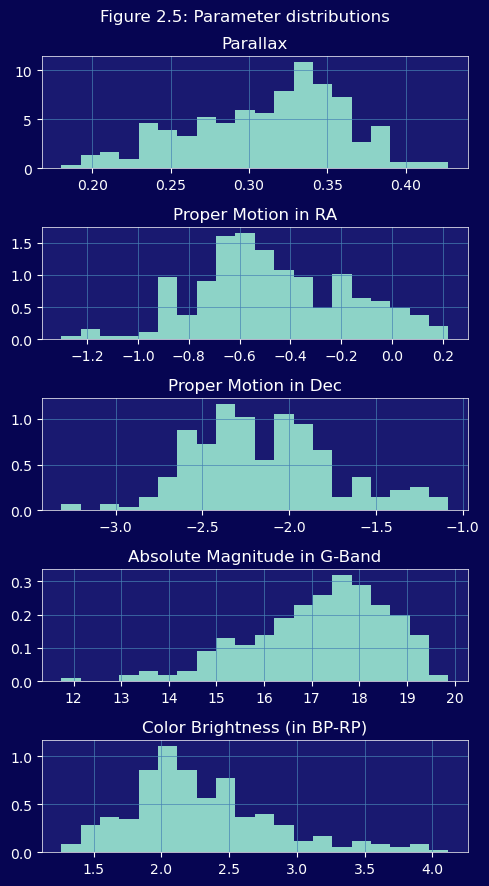

In [308]:
fig, ax = plt.subplots(5, 1, figsize = (5,9))
ax[0].hist(my_cluster['Plx'], density = True, bins = 20, label = 'Plx')
ax[0].set_title('Parallax')
ax[1].hist(my_cluster['pmRA'], density = True, bins = 20)
ax[1].set_title('Proper Motion in RA')
ax[2].hist(my_cluster['pmDE'], density = True, bins = 20)
ax[2].set_title('Proper Motion in Dec')
ax[3].hist(my_cluster['Gmag'], density = True, bins = 20)
ax[3].set_title('Absolute Magnitude in G-Band')
ax[4].hist(my_cluster['BP-RP'], density = True, bins = 20)
ax[4].set_title('Color Brightness (in BP-RP)')
plt.suptitle('Figure 2.5: Parameter distributions')
plt.tight_layout()

#### ***2d.** Based on the parameter distributions you plot, is the t-test an appropriate test in all cases?*

The t-test is not appropriate in all cases, given potential violations of the required assumptions: 
- Normal distribution: even though this should be fine at large N, *some* of the subsample PDFs in Figures 2.1-2.4 seem to have some heavy tails that could render this assumption to be problematic, or at least not completely satisfied. 
- Equal variance: seems roughly true, however some plots show unequal dispersions between subsamples (Gmag and BP-RP plots of Figure 2.4) that could corrupt this assumption. 



----------------------------------------------------------------

## 3. Hypothesis testing (7 pts): 
#### *Now you will analyse all the clusters in your new sample (i.e. star counts > 200, constrained in RA and Dec standard deviation).*
***3a.** Before computing any p-values, choose exactly one expectation about the distribution of p-values across your sample of clusters, based on the table below (include your expectations in your Jupyter notebook). Justify your choices, each in one sentence. Reference one figure or observation from a previous exercise to justify your expectation.*

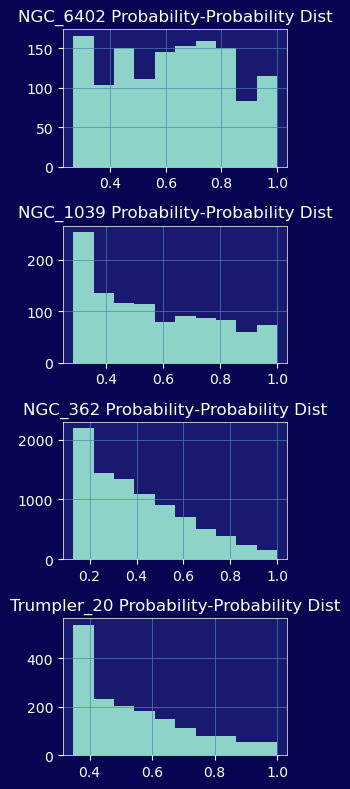

In [313]:
orig_clusters = ['NGC_6402', 'NGC_1039', 'NGC_362', 'Trumpler_20']
fig, ax = plt.subplots(4, 1, figsize = (3,8))
for (i, cluster) in enumerate(orig_clusters): 
    ax[i].hist(stars[stars['Name']==cluster]['Prob'])
    ax[i].set_title(f'{cluster} Probability-Probability Dist')
plt.tight_layout()

- **Plx (RA split): skewed low**; this is based on the fact that the parallax plot for NGC_6402 in my scatter plot matrix (exercise 1) seemed was more spread out along (more spread out to the right) and was the only one with a a higher amount of stars in the cluster with a high probability of being in the cluster (so more representative of this new sample of clusters) -- also, it became clear that spatial clustering was a dominant factor in the probability metric, and now we are in a high probability realm, so this should skew the distribution low. 

- **pmRA (RA split): skewed low**; based on the results in the `RA_results` table and the `Dec_results` table from the initial hypothesis tests; `pmRA` for the RA-split has a $p$-value of 0.00179 (significant by my threshold), while for the Dec-split it has $p$-value of 0.2576. Also based on the histogram for the RA split of `pmRA` in the previous exercise, there is a clear relationship between these parameters (which I think makes sense, as one is a measurement involving the other?)

- **BP-RP (Dec split): uniform**; while in the previous experiement on the one cluster, BP-RP had a significant $p$-value for the RA-split, I believe this should not be due to a population characteristic but rather that specific cluster. While it might make sense in theory for a rotating cluster to peak in the BP-RP band on one side due to redshifting, this should not be uniform across all clusters (they should have a random distribution of rotation axes which would remove skewing due to the declination parameter...)

#### ***3b.** Control test: Before looking for spatial variation, validate your method. For every cluster, randomly shuffle the stars into two groups (ignoring RA/Dec) and perform the t-test on `pmRA`. Plot the histogram of these p-values.*

Note: I am redoing the selection threshold as I feel it would be more beneficial to have a larger sample (my threshold for the previous was Prob > 0.85), but now I would like to change it back to 0.8. 

In [378]:
# re-doing original subset from part 2
p_thresh_2 = 0.8
stars_hiprob2 = stars[stars.Prob > p_thresh_2]
clusters_hiprob2 = stars_hiprob2.groupby(['Name']).size().reset_index(name='count')
clusters_sd_hiprob2 = stars_hiprob2.groupby(['Name']).std(numeric_only=True).reset_index()
clusters_hiprob2['sd_RAdeg'] = clusters_sd_hiprob2['RAdeg']
clusters_hiprob2['sd_DEdeg'] = clusters_sd_hiprob2['DEdeg']
cl_hiprob_gt200_2 = clusters_hiprob2[clusters_hiprob2['count']>200].sort_values('count')
clhp_gt200_stdltp1_2 = cl_hiprob_gt200_2[(cl_hiprob_gt200_2['sd_DEdeg'] < 0.1) & (cl_hiprob_gt200_2['sd_RAdeg'] < 0.1)]
names_subset_even = np.array(clhp_gt200_stdltp1['Name'].iloc[:-1])
names_subset_even_2 = np.array(clhp_gt200_stdltp1_2['Name'].iloc[:-1]) # clipping so that I can get an even number for split
new_subset_4 = stars_hiprob2[stars_hiprob2['Name'].isin(names_subset_even_2)]
# making sure it's the right length 
new_subset_grouped_4 = new_subset_4.groupby(['Name']).size().reset_index(name='count')
len(new_subset_grouped_4) == len(names_subset_even_2)

True

Text(0, 0.5, 'Density')

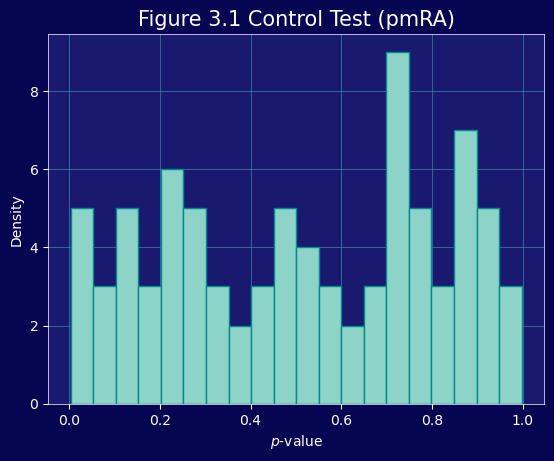

In [ ]:
p_values = [] # create empty list for p-values for later 

for cluster in new_subset_4['Name'].unique(): # separate by cluster name
    # random star sorting per cluster
    indiv_cluster = new_subset_4[new_subset_4['Name']==cluster] # get cluster alone 
    rng = np.random.default_rng(abs(hash(cluster)) % 2**32) # seed each time with random seed but save to each cluster hash (help from ChatGPT)
    shuffled_index = rng.permutation(indiv_cluster.index) # get a new, random index (rng.permutation: help from ChatGPT)
    stars1_idx, stars2_idx = np.array_split(shuffled_index, 2) # split shuffled index 
    half_stars1 = indiv_cluster.loc[stars1_idx] # get two cluster groups with split shuffled indices
    half_stars2 = indiv_cluster.loc[stars2_idx] 
    # hypothesis test for pmRA
    t_stat, pvalue = sp.stats.ttest_ind(a = half_stars1['pmRA'].to_numpy(),  # run hypothesis test
                                        b = half_stars2['pmRA'].to_numpy())
    p_values.append({'cluster':cluster, 'p-value':pvalue}) # save to list

# assess 
pval_df = pd.DataFrame(p_values)
plt.hist(pval_df['p-value'], edgecolor = 'darkcyan', bins = 20, zorder=3)
plt.grid(zorder = 0)
plt.title('Figure 3.1 Control Test (pmRA)', size = 15)
plt.xlabel('$p$-value')
plt.ylabel('Density')

Cool. This looks uniformly distributed. 

#### ***3c.** For all clusters in your sample, perform the t-tests from exercise 2c on `Plx`, `pmRA` and `BP-RP`, with both RA and Dec splits. For each parameter and coordinate (RA or Dec) being tested, plot the resulting p-values in a histogram (so you have 6 histograms in total, each calculated from $N_c$ p-values where $N_c$ is the number of clusters analysed). Use identical binning, include a vertical line at $p=0.05$ and produce figures that span $[0, 1]$ in $p$. Include the number of clusters used in the Figure title.*

In [376]:
def perform_t_test(a, b): 
    '''perform two-sample t-test'''
    _, pvalue = sp.stats.ttest_ind(a, b) 
    return pvalue

p_values_all = []
test_params = ['Plx', 'pmRA', 'BP-RP']

for cluster in new_subset_4['Name'].unique():
    # 
    indiv_cluster = new_subset_4[new_subset_4['Name']==cluster] #isolate cluster dataframe
    # split them by RAs and DECs
    RA_split = [indiv_cluster[indiv_cluster['RAdeg'] < np.mean(indiv_cluster['RAdeg'])], 
                indiv_cluster[indiv_cluster['RAdeg'] > np.mean(indiv_cluster['RAdeg'])]]
    Dec_split = [indiv_cluster[indiv_cluster['DEdeg'] < np.mean(indiv_cluster['DEdeg'])], 
                indiv_cluster[indiv_cluster['DEdeg'] > np.mean(indiv_cluster['DEdeg'])]]
    # perform hypothesis tests
    pval_per_param = []
    for param in test_params: 
        p_value_RAsplit = perform_t_test(RA_split[0][param], RA_split[1][param])
        p_value_Decsplit = perform_t_test(Dec_split[0][param], Dec_split[1][param])
        pval_per_param.append([param, p_value_RAsplit, p_value_Decsplit])
    
    # save to overall 
    p_values_all.append({'cluster': cluster, 
                         'Plx_pval_RA': pval_per_param[0][1], 
                         'Plx_pval_Dec': pval_per_param[0][2], 
                         'pmRA_pval_RA': pval_per_param[1][1], 
                         'pmRA_pval_Dec': pval_per_param[1][2],
                         'BP-RP_RA': pval_per_param[2][1],
                         'BP-RP_Dec': pval_per_param[2][2]
                         })
    
p_val_df = pd.DataFrame(p_values_all)
p_val_df

,cluster,Plx_pval_RA,Plx_pval_Dec,pmRA_pval_RA,pmRA_pval_Dec,BP-RP_RA,BP-RP_Dec
0,Berkeley_36,0.984495,0.552106,0.357587,0.674851,2.441178e-03,0.007307
1,Berkeley_39,0.286842,0.975245,0.774248,0.293443,2.811000e-02,0.451651
2,Berkeley_43,0.131550,0.045284,0.969217,0.637010,9.123859e-02,0.021832
3,Collinder_110,0.252296,0.585649,0.062747,0.368742,4.288328e-01,0.017785
4,Czernik_41,0.104860,0.669607,0.677511,0.189816,4.082272e-07,0.000031
...,...,...,...,...,...,...,...
79,Trumpler_25,0.263779,0.154468,0.148568,0.243992,1.646241e-03,0.005530
80,Trumpler_5,0.417152,0.422506,0.851845,0.150595,1.111742e-05,0.017443
81,UBC_1020,0.533884,0.510737,0.911368,0.207143,9.117614e-01,0.000670
82,UBC_106,0.631492,0.847182,0.390937,0.386322,2.042062e-01,0.036870


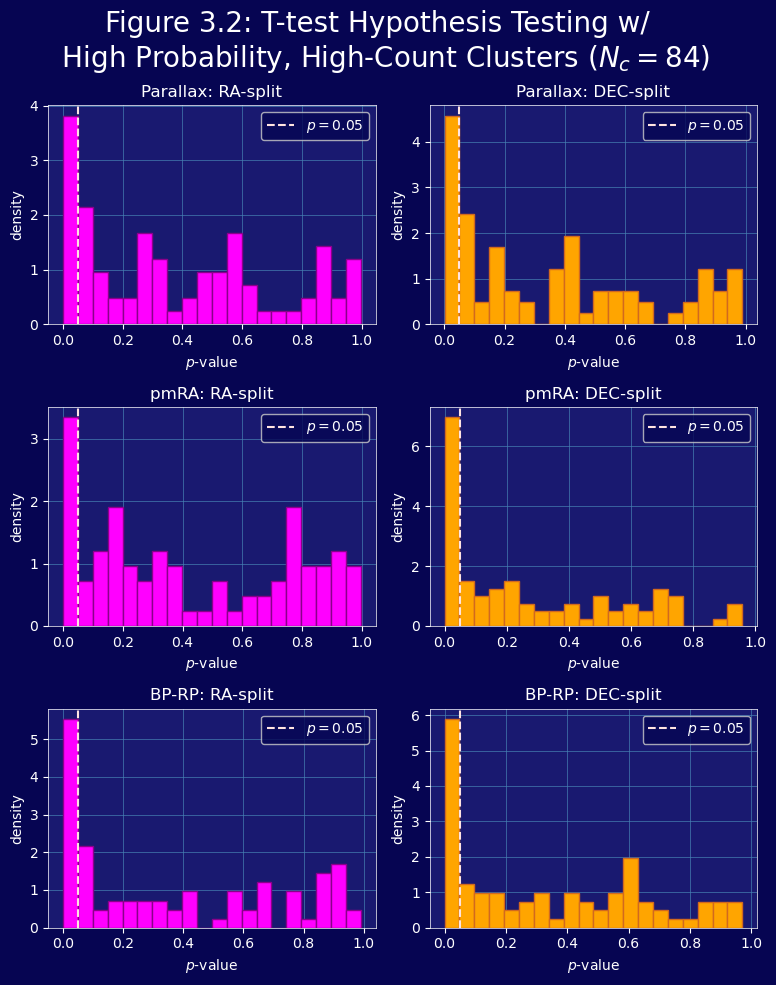

In [377]:
# plotting

fig, ax = plt.subplots(3,2, figsize = (8, 10))

# parallax
ax[0,0].hist(p_val_df['Plx_pval_RA'], color = 'magenta', edgecolor = 'darkmagenta', bins = 20, density=True, zorder=3)
ax[0,0].set_title('Parallax: RA-split')
ax[0,0].grid(True, zorder=0)      
ax[0,1].hist(p_val_df['Plx_pval_Dec'], color = 'orange', edgecolor='chocolate', bins = 20, density=True, zorder=3)
ax[0,1].set_title('Parallax: DEC-split')
ax[0,1].grid(True, zorder=0)

# pmRA
ax[1,0].hist(p_val_df['pmRA_pval_RA'], color = 'magenta', edgecolor = 'darkmagenta', bins = 20, density=True, zorder=3)
ax[1,0].set_title('pmRA: RA-split')
ax[1,0].grid(True, zorder=0)
ax[1,1].hist(p_val_df['pmRA_pval_Dec'], color = 'orange', edgecolor='chocolate', bins = 20, density=True, zorder=3)
ax[1,1].set_title('pmRA: DEC-split')
ax[1,1].grid(True, zorder=0)

# BP-RP
ax[2,0].hist(p_val_df['BP-RP_RA'], color = 'magenta', edgecolor = 'darkmagenta', bins = 20, density=True, zorder=3)
ax[2,0].set_title('BP-RP: RA-split')
ax[2,0].grid(True, zorder=0)
ax[2,1].hist(p_val_df['BP-RP_Dec'], color = 'orange', edgecolor='chocolate', bins = 20, density=True, zorder=3)
ax[2,1].set_title('BP-RP: DEC-split')
ax[2,1].grid(True, zorder=0)

for axis in ax.flat:
    axis.axvline(x=0.05, zorder=4, ls = 'dashed', color = 'mistyrose', label = '$p = 0.05$')
    axis.legend()

plt.setp(ax, xlabel='$p$-value', ylabel='density')
plt.suptitle('Figure 3.2: T-test Hypothesis Testing w/ \n High Probability, High-Count Clusters ($N_c = 84$)', size = 20)
plt.tight_layout()

#### ***3d.** For at least one of the three expectations you justified above, answer the following questions (make sure to include references to at least one specific figure and to features within that figure):*

1. *Which description best matches the histogram? (1) consistent with uniform, (2) excess of small p-values, (3) depleted at small p-values*
2. *Which explanation is the most plausible, and which is least plausible: (1) Genuine spatial substructure, (2) violation of test assumptions, (3) selection effects from earlier cuts, (4) pure chance*

#### Focusing on the BP-RP result, but the analysis somewhat goes for all of the expectations. 

1. Best description: **(2) excess of small p-values**, as is clear in the bottom two histograms of the plot above (abundance of p-values below the 0.05 threshold). 
2. Most plausible explanation: **(3) selection effects from earlier cuts**, least plausible: **(4) pure chance**. However, I also think that (3) could happen as a result of (2), but not as definitively.  

I was wrong about the BP-RP being uniform. I imagine this must be due to selection effects, perhaps where photometry was used in the algorithm for probability clustering, or something of that nature. 

#### ***3e.** You performed $N_c \times 3$ tests. How many p-values <0.05 did you find? How many would you expect by pure chance if there were no spatial differences? Based on this, estimate the False Discovery Rate (Observed Positives / Expected False Positives). Is p<0.05 a good threshold? What would you choose? Justify your choice based on one specific figure (include the Figure number you are referring to in your answer) or on one specific number you have calculated.*

In [ ]:
# in this cell: getting p values for the total and for the individual 
# RA and DEC splits to pull out values < 0.05
cols = ['Plx_pval_RA', 'Plx_pval_Dec', 'pmRA_pval_RA',
       'pmRA_pval_Dec', 'BP-RP_RA', 'BP-RP_Dec']
all_pvals = pd.concat([p_val_df[c] for c in cols], ignore_index=True)
print(f'Number of total p-values < 0.05: {len(all_pvals[all_pvals < 0.05])}')
RAcols = ['Plx_pval_RA', 'pmRA_pval_RA', 'BP-RP_RA']
DECcols = ['Plx_pval_Dec', 'pmRA_pval_Dec', 'BP-RP_Dec']
RA_pvals = pd.concat([p_val_df[c] for c in RAcols], ignore_index=True)
DEC_pvals = pd.concat([p_val_df[c] for c in DECcols], ignore_index=True)
print(f'Number of total RA-test p-values < 0.05: {len(RA_pvals[RA_pvals < 0.05])} ({len(RA_pvals[RA_pvals < 0.05])/len(RA_pvals)*100:.0f}%)')
print(f'Number of total DEC-test p-values < 0.05: {len(DEC_pvals[DEC_pvals < 0.05])} ({len(DEC_pvals[DEC_pvals < 0.05])/len(DEC_pvals)*100:.0f}%)')
print(f'Minimum p-value found: {min(all_pvals)}')
print(f'Maximum p-value found: {max(all_pvals)}')

Number of total p-values < 0.05: 124
Number of total RA-test p-values < 0.05: 53 (21%)
Number of total DEC-test p-values < 0.05: 71 (28%)
Minimum p-value found: 8.089176989629627e-52
Maximum p-value found: 0.9973026237167253


If there were no spatial differences, that would mean that the means of the RA and DEC splits would be equal (the null hypothesis), and we would expect 5% of the tests to result with $p < 0.05$.

$N_{p\lt0.05} = 0.05 \times N_{tests}$, where $N_{tests}$ in my sample is $N_{params} \times N_{clusters}$. 

In [337]:
N_exp_null_sep = 0.05 * 3 * 84 # separating by the RA and DEC splits
print(f'Expected number of p-values < 0.05 per spatial category = {N_exp_null_sep}')
N_exp_null_all = 0.05 * 6 * 84 # for whole testing system
print(f'Expected number of p-values < 0.05 for all six tests = {N_exp_null_all}')

Expected number of p-values < 0.05 per spatial category = 12.600000000000001
Expected number of p-values < 0.05 for all six tests = 25.200000000000003


For the false, discovery rate: 
$$
\text{FDR} = \frac{N_{obs}}{N_{exp}}
$$

In [338]:
fdr_RAs = (len(RA_pvals[RA_pvals < 0.05]))/N_exp_null_sep
fdr_DECs = (len(DEC_pvals[DEC_pvals < 0.05]))/N_exp_null_sep
fdr_all = (len(all_pvals[all_pvals < 0.05]))/N_exp_null_all

print(f'False Discovery Rate for RA split: {fdr_RAs}')
print(f'False Discovery Rate for DEC split: {fdr_DECs}')
print(f'False Discovery Rate for all tests: {fdr_all}')

False Discovery Rate for RA split: 4.206349206349206
False Discovery Rate for DEC split: 5.634920634920634
False Discovery Rate for all tests: 4.92063492063492


Clearly $p<0.05$ is not a good threshold (in addition to the other problems with this hypothesis testing), as we would want the false discovery rate to be way closer to 1. 

As we learned in lecture, one must consider the number of trials when computing significance. Therefore, we would want to divide the desired p-value by the number of tests. So if we are looking only at the RA or DEC splits, we would want 
$$
p < \frac{0.05}{N_{tests}} = \frac{0.05}{3\times84} = 0.0001984
$$

#### ***3f**. Should you base your scientific conclusion about the spatial distribution of stellar properties on the tests you’ve performed above? Why or why not? Motivate your answer using the at least one of the quantities and figures you’ve generated above.*

I should not base my scientific conclusion about the spatial distribution of stellar properties on the tests I've performed above, both because as I just calculated, the significance threshold is too high (p >> 0.00019) as is evidenced by the false positives rate, and also the t-test assumptions are multiply violated as I have discussed previously (skewed distributions, filtering, etc.). Rejecting the null hypothesis for these results is purely statistical (due to this particular setup), and can be motivating, but I should not be using significance from these tests *alone* as a basis for any kind of conclusion. 

----------------------------------------------------------------

# 4. Hypothesis testing significance versus sample size: (6 pts)
#### In very large datasets, even tiny, physically irrelevant deviations can produce extremely small p-values because the standard error of the mean shrinks as 1/√𝑁. We need to determine if our "significant" results are physically meaningful or just a byproduct of having a lot of data. For this exercise, use the original `clusters_hiprob` DataFrame (i.e. without filtering for RA and Dec) in order to have a sufficient number of clusters.

#### Choosing Parameter: BP-RP (DEC-split)
Note: it was unclear if this sample should also be with a count greater than 200. I decided to just go with the high probability threshold and leave it there (why not more data). 

(Around two minutes for this cell)

In [ ]:
stars_hiprob3 = stars[stars['Prob']>0.8]
clusters_hiprob3 = stars_hiprob3.groupby(['Name']).size().reset_index(name='count')
pvals_BPRP = []
for cluster in stars_hiprob3['Name'].unique():
    indiv_cluster = stars_hiprob3[stars_hiprob3['Name']==cluster] #isolate cluster dataframe
    # split them by DECs
    Dec_split = [indiv_cluster[indiv_cluster['DEdeg'] < np.mean(indiv_cluster['DEdeg'])], 
                indiv_cluster[indiv_cluster['DEdeg'] > np.mean(indiv_cluster['DEdeg'])]]

    p_value_Decsplit = perform_t_test(Dec_split[0]['BP-RP'], Dec_split[1]['BP-RP'])
    
    # save to overall 
    pvals_BPRP.append({'cluster': cluster,
                         'p-value': p_value_Decsplit, 
                         'count': clusters_hiprob3.loc[clusters_hiprob3['Name'] == cluster, 'count'].iloc[0]})
    
p_val_BPRP = pd.DataFrame(pvals_BPRP)

In [114]:
p_val_BPRP

,cluster,p-value,count
0,1636-283,0.330256,30
1,ADS_16795,0.508114,41
2,AH03_J0748+26.9,0.344393,28
3,ASCC_100,0.393445,87
4,ASCC_101,0.354570,149
...,...,...,...
7162,vdBergh_152,0.546467,25
7163,vdBergh_80,0.268228,93
7164,vdBergh_83,0.353164,92
7165,vdBergh_85,0.001305,105


In [124]:
p_val_BPRP['count'].describe()

count    7167.000000
mean       74.517511
std       156.908500
min        10.000000
25%        28.000000
50%        49.000000
75%        91.000000
max      6339.000000
Name: count, dtype: float64

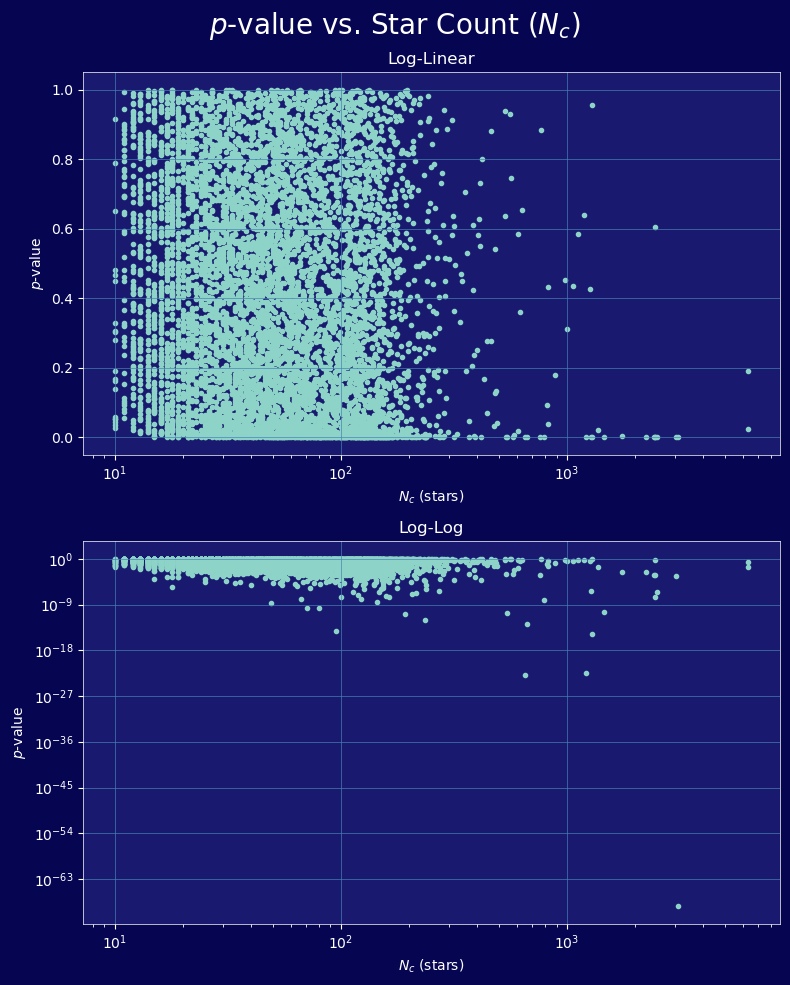

In [223]:
fig, ax = plt.subplots(2,1, figsize = (8,10))

ax[0].scatter(p_val_BPRP['count'],p_val_BPRP['p-value'], marker='.')
ax[0].set_xscale('log')
ax[0].set_ylabel('$p$-value')
ax[0].set_xlabel('$N_c$ (stars)')
ax[0].set_title('Log-Linear')

ax[1].scatter(p_val_BPRP['count'],p_val_BPRP['p-value'], marker='.')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_ylabel('$p$-value')
ax[1].set_xlabel('$N_c$ (stars)')
ax[1].set_title('Log-Log')

plt.suptitle('$p$-value vs. Star Count ($N_c$)', size = 20)
plt.tight_layout()

#### ***3b.** Calculate the correlation coefficient (e.g., Pearson or Spearman) between $N_c$ and the p-value (hint: this may work better in the logarithm of $N_c$ and p). Does the correlation suggest that larger clusters are "more significant" (lower p-values)?*

In [339]:
import scipy.stats as sps

# putting things into log for ease w correlations
log_pvals = np.log(p_val_BPRP['p-value'])
log_Nc = np.log(p_val_BPRP['count'])

# got this from the course site
(rcor, rpval) = sps.pearsonr(log_Nc,log_pvals)
(rhocor, rhopval) = sps.spearmanr(log_Nc,log_pvals)

print("Pearson's r and p-value:",rcor, rpval)
print("Spearman's rho and p-value:",rhocor, rhopval)

Pearson's r and p-value: -0.1985313464004517 1.2883155047676885e-64
Spearman's rho and p-value: -0.12038956880036436 1.494861106328562e-24


This does not "suggest that larger clusters are more significant," but rather suggests that: when doing hypothesis testing on this parameter for this data set, clusters with larger star counts tend to result in a smaller p-value. But we cannot say that the larger clusters are simply "more significant." This tells us about the test we've run and the data we are using. (Correlation does not imply causation, even within the statistical test.) 

#### ***4c** Identify the cluster with the lowest p-value in your sample. For this specific cluster, plot the distributions and calculate the actual difference in means between the two subsamples: $\Delta\mu = |\mu_1 - \mu_2|$.*

In [340]:
p_val_BPRP_min = p_val_BPRP[p_val_BPRP['p-value']==min(p_val_BPRP['p-value'])]
print(p_val_BPRP_min.iloc[0])

cluster    Theia_3623
p-value           0.0
count            3086
Name: 5785, dtype: object


Text(0, 0.5, 'Density')

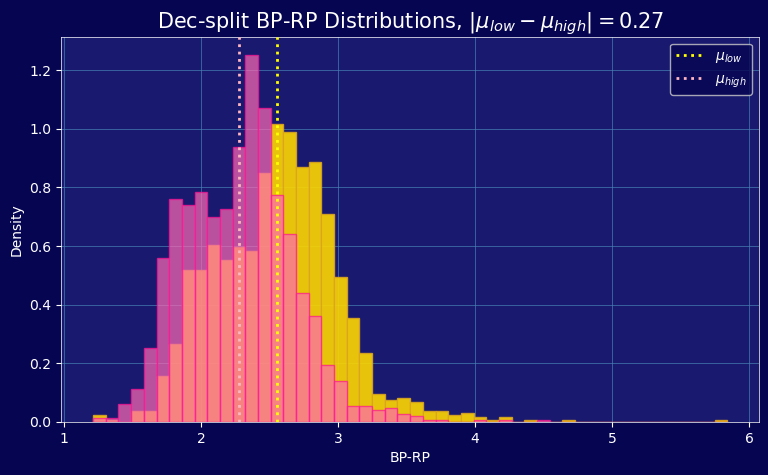

In [341]:
Theia = stars_hiprob3[stars_hiprob3['Name']=='Theia_3623']
Theia_dec_split = [Theia[Theia['DEdeg'] < np.mean(Theia['DEdeg'])], 
                   Theia[Theia['DEdeg'] > np.mean(Theia['DEdeg'])]]

delta_mu = np.abs(np.mean(Theia_dec_split[0]['BP-RP']) - np.mean(Theia_dec_split[1]['BP-RP']))

# want to have shared bin width on plot, finding good bins
bins = np.linspace(Theia['BP-RP'].min(), Theia['BP-RP'].max(), 51)

plt.figure(figsize = (9,5))
plt.grid(zorder=0)
_ = plt.hist(Theia_dec_split[0]['BP-RP'], density=True, color = 'gold', edgecolor = 'goldenrod', alpha = 0.9, bins = bins, zorder=3)
_ = plt.hist(Theia_dec_split[1]['BP-RP'], density=True, color = 'hotpink', edgecolor = 'deeppink', alpha = 0.7, bins = bins, zorder=3)
plt.axvline(np.mean(Theia_dec_split[0]['BP-RP']), ls = 'dotted', lw = 2, color = 'yellow', label = '$\mu_{low}$', zorder=4)
plt.axvline(np.mean(Theia_dec_split[1]['BP-RP']), ls = 'dotted', lw = 2, color = 'lightpink', label = '$\mu_{high}$', zorder=4)
plt.legend()
plt.title(f'Dec-split BP-RP Distributions, $|\mu_{{low}} - \mu_{{high}}| = {delta_mu:.2f}$', size = 15)
plt.xlabel('BP-RP')
plt.ylabel('Density')

#### ***4d.** Compare this $\Delta \mu$ to the dispersion $\sigma$ of the cluster.*

In [342]:
sigma = Theia['BP-RP'].std()
print(f'𝜎 = {sigma:.2f}')
print(f'Δ𝜇 = {delta_mu:.2f}')
print(f'Δ𝜇/𝜎 = {delta_mu/sigma:.2f}')

𝜎 = 0.44
Δ𝜇 = 0.27
Δ𝜇/𝜎 = 0.62


The standard deviation $\sigma$ $\sim$ the effect size $\Delta \mu$ by the same order of magnitude. ($\Delta\mu/\sigma = 0.62$)

#### ***4e**. Based on the scatter plot and the effect size Δ𝜇, do you believe the spatial variations in these clusters are astrophysically important (indicating real structure like rotation/tides) or merely statistically detectable due to large $N_c$?*

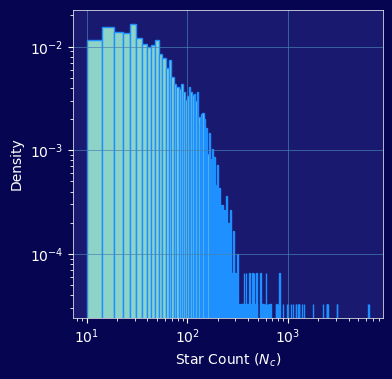

In [343]:
plt.figure(figsize = (4,4))
plt.hist(clusters_hiprob3['count'], density=True, edgecolor = 'dodgerblue', bins=1500)
plt.xlabel('Star Count ($N_c$)')
plt.ylabel('Density')
plt.xscale('log')
plt.yscale('log')

Based on the scatter plot and the effect size $\Delta\mu$, I think it is more likely that they are statistically detectable due to large $N_c$. Given that the effect size is within an order of magnitude of the standard deviation, I know that there *could* be some real structure, but a physical argument is beyond the scope of the data. And while technically this result requires rejecting the null hypothesis, looking at the scatter plot, this Theia cluster is clearly an outlier, even among p-values on the lower end it is quite low, and thus I think it appears to be a dimension effect ($N_c$). 

There is a chance that this could be due to some kind of real structure (rotation/tides), however in this case, there is no way to test that given this subsample, which also shines light on the problem with this whole analysis, which is based on a filtering of only stars above a threshold probability (here, P>0.8) of being a member of a cluster; then, this probability parameter itself is determined by an algorithm which itself is determined predominantly by spatial clustering (confirmed, read through a bit of Hunt and Reffert 2023). 

I was actually curious how these probabilities work out with the star counts, given the catalogue itself (shown in the slightly weird log histogram above) contains an unequal amount of low-count clusters and high-count clusters (this is also in line with Figure 2 (bottom) of Hunt and Reffert 2023). I was curious how the probability itself varied over the whole set. 

In [ ]:
# around 4 minutes for this one

vars = []
for cluster in stars['Name'].unique():
    cluster_spec = stars[stars['Name']==cluster]
    var = cluster_spec['Prob'].std()
    vars.append({'cluster': cluster, 'count': len(cluster_spec), 
                 'prob': cluster_spec['Prob'], 'prob_sigma': var})


prob_df = pd.DataFrame(vars)

Text(0.5, 1.0, 'Figure A.1: Candidate Probabilities Distribution')

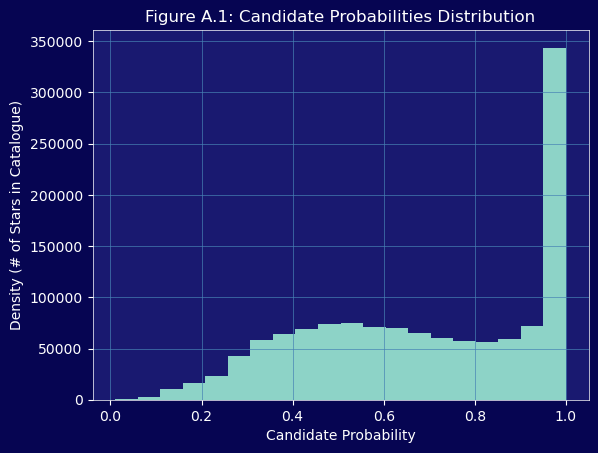

In [370]:
_ = plt.hist(stars['Prob'], bins=20)
plt.xlabel('Candidate Probability')
plt.ylabel('Density (# of Stars in Catalogue)')
plt.title('Figure A.1: Candidate Probabilities Distribution')

So, at least this shows that when we did our "high probability" sub-sample above 0.8, it still was not a randomly distributed sample in the probability space, and definitely far from Gaussian with that stacking at 1. *This makes sense for trying to make a good catalogue of clusters!* But also should make it hard to make physical inferences from statistical tests which rely on the statistical tests we used (because selection invalidates most). 

Text(0.5, 1.0, 'Figure A.2: median probability per cluster star count')

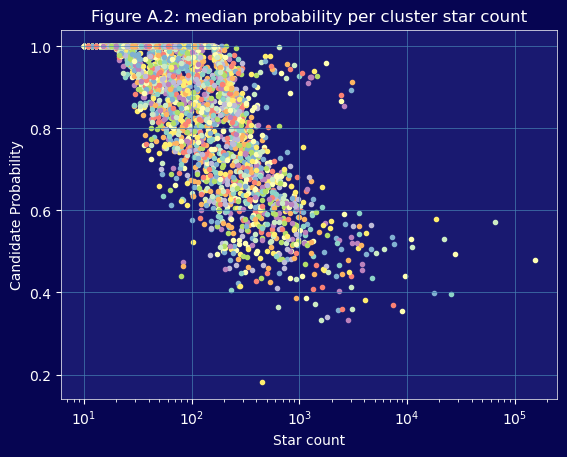

In [375]:
plt.figure()
for i in range(len(prob_df)):
    plt.scatter(prob_df['count'][i], np.median(prob_df['prob'][i]), marker='.')
plt.xscale('log')
plt.xlabel('Star count')
plt.ylabel('Candidate Probability')
plt.title('Figure A.2: median probability per cluster star count')

Text(0.5, 1.0, 'Figure A.3: Probability $\\sigma$')

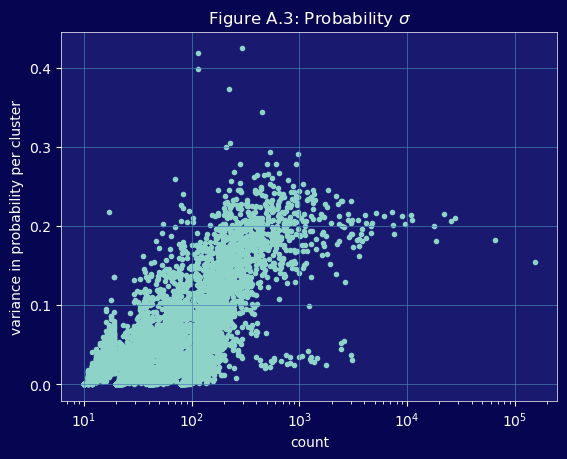

In [371]:
plt.scatter(prob_df['count'], prob_df['prob_sigma'], marker = '.')
plt.xlabel('count')
plt.ylabel('variance in probability per cluster')
plt.xscale('log')
plt.title('Figure A.3: Probability $\sigma$')

Text(0.5, 1.0, 'Figure A.4: Probability Variance Distribution')

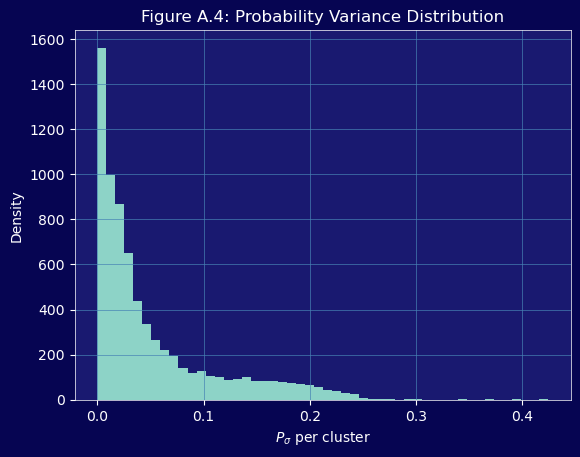

In [373]:
_ = plt.hist(prob_df['prob_sigma'], bins = 50)
plt.xlabel('$P_{\sigma}$ per cluster')
plt.ylabel('Density')
plt.title('Figure A.4: Probability Variance Distribution')

Text(0.5, 1.0, 'Figure A.5: Theia_3623 Prob. Distribution')

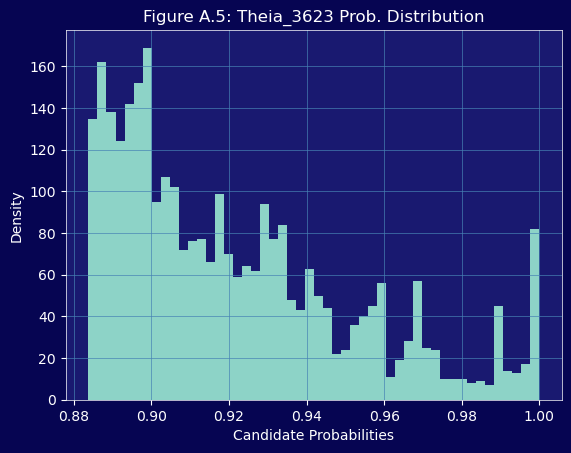

In [374]:
_ = plt.hist(Theia['Prob'], bins = 50)
plt.xlabel('Candidate Probabilities')
plt.ylabel('Density')
plt.title('Figure A.5: Theia_3623 Prob. Distribution')

This was all in an exercise to try to understand more deeply why this type of hypothesis testing didn't work here. I think I understand the underlying idea that many star clusters should have basically Gaussian distributions, thus making it intuitive to run these kinds of tests, but what I would still like to know is whether or not pre-sorting for the high probability stars was impacting things so heavily. I believe it does, given that lower probability star candidates would have made the cluster distributions tend more towards a normal distribution, but from the article (and from the Part 1 scatter plots), it seems like that is also a trade-off, as the smaller clusters are much more noisy and hard to discern. 

These plots (especially the 2nd and 3rd) were my way of trying to figure out what was going on with that outlier cluster in particular. I plotted this final plot (A.5 Theia_3623) while working on Part 4 and was confused how a (conceptually, I knew I filtered this way on purpose) cluster could have *so* many stars and also *only* have above 0.88 probability for its constituent star candidates. Now, I imagine that this cluster lies on that little wing that comes out on the middle-top bottom of Figure A.2 and middle-bottom of Figure A.3. These clusters have a lot of stars but manage to differentiate in the security of their designation (affirming stars are members). I wonder why this sub-group splits off this way? Perhaps closer and easier to count... 